Here, we use the GINCO and EN-GINCO datasets that have been fully annotated by 2 annotators. We apply the GPT-4o on the datasets and compare its agreement with the annotators with the agreement between the annotators.

Use the emma_main kernel

In [1]:
# Define the gpu on the gpu machine
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0

import pandas as pd
import json
import numpy as np
import tarfile
import os
from collections import Counter
import matplotlib.pyplot as plt
from time import sleep
from sklearn.model_selection import train_test_split
from openai import OpenAI
from tqdm import tqdm
client = OpenAI(api_key=open('key.txt').read())

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0


## GINCO labels

The labels are encoded in three levels of detail, allowing experiments with:
- the full set of labels (`level_1` - 24 labels):
['Announcement', 'Call', 'Correspondence', 'FAQ', 'Forum', 'Information/Explanation', 'Instruction', 'Interview', 'Invitation', 'Legal/Regulation', 'List of Summaries/Excerpts', 'Lyrical', 'News/Reporting', 'Opinion/Argumentation', 'Opinionated News', 'Other', 'Promotion', 'Promotion of Services', 'Promotion of a Product', 'Prose', 'Recipe', 'Research Article', 'Review', 'Script/Drama']

- the set of 21 labels (`level_2` - first downcasting: labels with less than 5 instances are merged with label Other):
['Announcement', 'Call', 'Correspondence', 'Forum', 'Information/Explanation', 'Instruction', 'Interview', 'Invitation', 'Legal/Regulation', 'List of Summaries/Excerpts', 'News/Reporting', 'Opinion/Argumentation', 'Opinionated News', 'Other', 'Promotion', 'Promotion of Services', 'Promotion of a Product', 'Prose', 'Recipe', 'Research Article', 'Review']

- the set of 12 labels (`level_3` - second downcasting: similar labels are merged, some less frequent labels are merged to Other):
['Announcement', 'Forum', 'Information/Explanation', 'Instruction', 'Interview', 'Legal/Regulation', 'List of Summaries/Excerpts', 'News/Reporting', 'Opinion/Argumentation', 'Opinionated News', 'Other', 'Promotion']


For the first downcasting (level 1 to level 2) we used the following mapping:
 ```
 {"Script/Drama":"Other", "Lyrical":"Other","FAQ":"Other"}
 ```

The second downcasting (level 2 to level 3) uses the mapping:
 ```
 {"Recipe":"Instruction", "Research Article":"Information/Explanation", "Review":"Opinion/Argumentation", "Promotion of Services":"Promotion", "Promotion of a Product":"Promotion", "Invitation":"Promotion", "Correspondence":"Other", "Prose":"Other", "Call":"Other"}

## Dataset preparation

In [6]:
file = pd.read_csv("/home/tajak/Genre-Datasets-Comparison/Creation-of-classifiers-and-cross-prediction/data-sheets-with-all-info/GINCO-MT-GINCO-keeptext-with-all-information.csv", sep="\t", index_col = 0)

file

,id,url,crawled,hard,primary_level_1,primary_level_2,primary_level_3,secondary_level_1,secondary_level_2,secondary_level_3,...,FTD_pred_on_SL,FTD_pred_on_MT,split-without-rare-categories,primary_level_4,downcast_split,CORE_main_pred_on_SL,CORE_main_pred_on_MT,CORE_sub_pred_on_SL,CORE_sub_pred_on_MT,primary_level_1_to_X-GENRE
0,3949,http://www.pomurje.si/aktualno/sport/zimska-li...,2014,False,News/Reporting,News/Reporting,News/Reporting,NaN,NaN,NaN,...,A8 (news),A8 (news),test,News/Reporting,test,Narrative,Narrative,Sports Report,Sports Report,News
1,3726,http://www.ss-sezana.si/sss/index.php?option=c...,2014,False,Information/Explanation,Information/Explanation,Information/Explanation,NaN,NaN,NaN,...,A16 (information),A16 (information),test,Information/Explanation,dev,Informational Description/Explanation,Informational Description/Explanation,Description of a Thing,Description of a Thing,Information/Explanation
2,5621,http://www.kamnik-starejsi.si/novice/144-sodel...,2014,False,Promotion of Services,Promotion of Services,Promotion,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation,...,A12 (promotion),A12 (promotion),train,Promotion,test,Informational Description/Explanation,Informational Description/Explanation,Description of a Thing,Description of a Thing,Promotion
3,3776,http://www.radiocelje.si/novica.php?id=13007&a...,2014,False,News/Reporting,News/Reporting,News/Reporting,NaN,NaN,NaN,...,A8 (news),A8 (news),train,News/Reporting,train,Informational Description/Explanation,Informational Description/Explanation,News Report/Blog,News Report/Blog,News
4,2102,http://www.mtv.si/novice/selena-gomez-ponudila...,2014,False,Opinionated News,Opinionated News,Opinionated News,NaN,NaN,NaN,...,A8 (news),A8 (news),test,News/Reporting,train,Narrative,Narrative,News Report/Blog,News Report/Blog,News
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,374730,http://khetanes.si/sl-si/produkti/projektne-no...,2021,False,Information/Explanation,Information/Explanation,Information/Explanation,NaN,NaN,NaN,...,A12 (promotion),A8 (news),test,Information/Explanation,test,Informational Description/Explanation,Informational Description/Explanation,Description of a Thing,Description of a Thing,Information/Explanation
998,476885,https://www.merkur.si/navigacija/nasveti/kopal...,2021,False,List of Summaries/Excerpts,List of Summaries/Excerpts,List of Summaries/Excerpts,NaN,NaN,NaN,...,A12 (promotion),A12 (promotion),train,List of Summaries/Excerpts,train,Informational Persuasion,Informational Persuasion,Description with Intent to Sell,Description with Intent to Sell,discarded
999,674213,http://www.sex2.si/category/ocene-izdelkov/,2021,False,List of Summaries/Excerpts,List of Summaries/Excerpts,List of Summaries/Excerpts,NaN,NaN,NaN,...,A12 (promotion),A12 (promotion),train,List of Summaries/Excerpts,train,Informational Persuasion,Informational Persuasion,Description with Intent to Sell,Description with Intent to Sell,discarded
1000,975590,http://www.ipsos.si/VodenjeVIZ_VI_past_dvojne_...,2021,False,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation,NaN,NaN,NaN,...,A1 (argumentative),A1 (argumentative),dev,Opinion/Argumentation,train,Informational Description/Explanation,Informational Description/Explanation,FAQ about Information,Question/Answer Forum,Opinion/Argumentation


In [33]:
# Keep only relevant columns
ginco = file[['id', 'hard', 'Slovene_text', 'primary_level_1', 'MT_text', 'split',]]

ginco.head(2)

,id,hard,Slovene_text,primary_level_1,MT_text,split
0,3949,False,"Šport <p/> Zimska liga malega nogometa sobota,...",News/Reporting,Sport <p/> Winter Little League Football Satur...,test
1,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train


In [34]:
ginco.shape

(1002, 6)

In [48]:
# Open the file with annotations

ginco_ann = pd.read_csv("datasets/ginco-two-annotators-labels.txt", sep="\t")

print(ginco_ann.shape)

ginco_ann.rename(columns={"ID":"id"}, inplace=True)

ginco_ann.head(2)

(1019, 5)


,id,Taja,Mojca,Final,Final different than both initial
0,3726,Information/Explanation,Information/Explanation,Information/Explanation,no
1,5621,Promotion of Services,Information/Explanation,Promotion of Services,no


In [49]:
# Merge the annotations to the ginco dataset based on ids

ginco_final = pd.merge(left=ginco, right=ginco_ann, how="inner", on="id")

ginco_final.head(3)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,Final,Final different than both initial
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation,no
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,Promotion of Services,no
2,3776,False,"V novembru, mesecu preprečevanja odvisnosti, b...",News/Reporting,"In November, the month of addiction prevention...",train,Invitation,News/Reporting,News/Reporting,no


In [50]:
ginco_final.shape

(996, 10)

In [59]:
# Remove instances where there is a NaN in "Taja" or "Mojca" column - this occurred because the final label to this instance was decided only at the point where the annotators discussed the differences (at the phase of assigning final annotations)
ginco_final = ginco_final.dropna(subset="Taja")
ginco_final = ginco_final.dropna(subset="Mojca")

In [65]:
# Remove texts that were assigned by at least one of the annotators to be unsuitable

ginco_final = ginco_final[ginco_final["Taja"] != "Non-textual"]
ginco_final = ginco_final[ginco_final["Mojca"] != "Multiple texts"]

ginco_final.shape

(990, 10)

In [51]:
ginco_final.columns

Index(['id', 'hard', 'Slovene_text', 'primary_level_1', 'MT_text', 'split',
       'Taja', 'Mojca', 'Final', 'Final different than both initial'],
      dtype='object')

In [44]:
# Clean the labels - correct labels if they do not appear in the label list
label_list = ['Announcement', 'Call', 'Correspondence', 'FAQ', 'Forum', 'Information/Explanation', 'Instruction', 'Interview', 'Invitation', 'Legal/Regulation', 'List of Summaries/Excerpts', 'Lyrical', 'News/Reporting', 'Opinion/Argumentation', 'Opinionated News', 'Other', 'Promotion', 'Promotion of Services', 'Promotion of a Product', 'Prose', 'Recipe', 'Research Article', 'Review', 'Script/Drama']

In [69]:
labels_to_check = list(ginco_final["Taja"].unique())

for label in labels_to_check:
	if label not in label_list:
		print(label)

In [70]:
# Check whether the final annotations agree
ginco_final.query("primary_level_1 != Final")[["Slovene_text", "primary_level_1", "Final"]]

,Slovene_text,primary_level_1,Final
3,Selena Gomez ponudila v poslušanje novi album ...,Opinionated News,News/Reporting
10,Lezbični in feministični klub v vsako vas Sobo...,Opinionated News,Opinion/Argumentation
18,PRIJETNO DRUŽENJE Z IZMENJAVO RABLJENIH OBLAČI...,Opinionated News,Opinion/Argumentation
23,Stoner bo sprejet med motociklistične legende ...,Opinionated News,News/Reporting
59,"Oče alkoholik uničuje življenje študentki, ki ...",Correspondence,Other
60,Farmacevt odgovarja <p/> Vprašanje: Pozdravlje...,Correspondence,Other
64,ODMEVI NA KNJIGO <p/> (Po e-pošti 24.06.2020 -...,Correspondence,Other
126,Pravice potnikov v letalskem prometu <p/> Ljud...,Instruction,Information/Explanation
160,"Javni razpis za izbor kulturnih programov, ki ...",Call,Information/Explanation
171,Šolska Malica <p/> PRIJAVA MALICE <p/> Na mali...,Instruction,Other


In [71]:
ginco_final.query("(primary_level_1 != Taja)&(primary_level_1 != Mojca)")[["Slovene_text", "primary_level_1", "Taja", "Mojca", "Final"]]

,Slovene_text,primary_level_1,Taja,Mojca,Final
3,Selena Gomez ponudila v poslušanje novi album ...,Opinionated News,Opinion/Argumentation,News/Reporting,News/Reporting
4,Razno <p/> Letos so Švicarji že tridesetič pri...,Promotion of a Product,Review,Information/Explanation,Promotion of a Product
10,Lezbični in feministični klub v vsako vas Sobo...,Opinionated News,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation
18,PRIJETNO DRUŽENJE Z IZMENJAVO RABLJENIH OBLAČI...,Opinionated News,Opinion/Argumentation,News/Reporting,Opinion/Argumentation
23,Stoner bo sprejet med motociklistične legende ...,Opinionated News,Opinion/Argumentation,News/Reporting,News/Reporting
...,...,...,...,...,...
958,"Sončne elektrarne se da pogasiti <p/> ""Sončne ...",Other,News/Reporting,News/Reporting,Other
960,34 milijardni prevzem Red Hata s strani IBM-a ...,Opinionated News,Opinion/Argumentation,News/Reporting,Opinionated News
962,Kaj ima skupnega vseh 500 najzmogljivejših sup...,Opinionated News,News/Reporting,News/Reporting,Opinionated News
963,O trgovinski vojni med ZDA in Kitajsko se zadn...,Opinionated News,Opinion/Argumentation,Opinion/Argumentation,Opinionated News


As we can see above, the label "Opinionated News" is problematic, because it was defined later in the annotation process as a reaction to instances that were between Opinion and News. For the purpose of this study, we will discard instances, annotated with this label, because the disagreement between the annotators in these cases was solely due to a blind spot in the annotation guidelines which was later solved by introduction of the label "Opinionated News".

In [101]:
ginco_final = ginco_final[ginco_final["primary_level_1"] != "Opinionated News"]
ginco_final = ginco_final[ginco_final["Taja"] != "Opinionated News"]
ginco_final = ginco_final[ginco_final["Mojca"] != "Opinionated News"]
ginco_final.shape

(847, 8)

In [82]:
ginco_final["primary_level_1"].value_counts()

primary_level_1
Information/Explanation       128
Promotion of a Product        115
News/Reporting                114
Opinion/Argumentation         112
List of Summaries/Excerpts    105
Forum                          50
Instruction                    37
Other                          33
Promotion of Services          32
Invitation                     31
Promotion                      30
Review                         17
Legal/Regulation               17
Announcement                   17
Correspondence                 16
Call                           11
Research Article                9
Interview                       8
Recipe                          6
Prose                           6
Lyrical                         3
FAQ                             3
Script/Drama                    1
Name: count, dtype: int64

Similarly, we discard instances labelled as "Correspondence" or "Call", as these labels were introduced during the annotation process and have not been present since the beginning of the annotation campaign.

In [102]:
ginco_final = ginco_final[ginco_final["primary_level_1"] != "Correspondence"]
ginco_final = ginco_final[ginco_final["primary_level_1"] != "Call"]
ginco_final = ginco_final[ginco_final["Taja"] != "Correspondence"]
ginco_final = ginco_final[ginco_final["Taja"] != "Call"]
ginco_final = ginco_final[ginco_final["Mojca"] != "Correspondence"]
ginco_final = ginco_final[ginco_final["Mojca"] != "Call"]
ginco_final.shape

(844, 8)

In [86]:
ginco_final.query("(primary_level_1 != Taja)&(primary_level_1 != Mojca)")[["Slovene_text", "primary_level_1", "Taja", "Mojca", "Final"]]

,Slovene_text,primary_level_1,Taja,Mojca,Final
4,Razno <p/> Letos so Švicarji že tridesetič pri...,Promotion of a Product,Review,Information/Explanation,Promotion of a Product
27,Ko dobimo otroka v svoje naročje je tako kot b...,Opinion/Argumentation,Promotion,Promotion of Services,Opinion/Argumentation
164,Main menu <p/> Post navigation <p/> Pogled na ...,Other,Promotion,Promotion,Other
171,Šolska Malica <p/> PRIJAVA MALICE <p/> Na mali...,Instruction,Legal/Regulation,Announcement,Other
181,V drugem delu uspešne filmske serije se bo mor...,Other,Prose,Promotion of a Product,Other
232,Govor predsednika Sveta za splošne zadeve in z...,Other,Opinion/Argumentation,Opinion/Argumentation,Other
295,Sporočila za javnost <p/> 14.12.2004 <p/> Hura...,Information/Explanation,Promotion,News/Reporting,Information/Explanation
365,Celoten »pulmo tim« Kliničnega oddelka za plju...,Other,News/Reporting,Promotion,Other
388,Naj projekt za mlade 2011 <p/> V okviru projek...,News/Reporting,Call,Promotion,News/Reporting
497,REDNI DELOVNI ČAS NAŠIH PRODAJALN <p/> Z izjem...,Promotion,Announcement,Promotion of Services,Promotion


In [96]:
# Additionally, we remove instances where the final label is different than the labels of either of the annotators - this means that in the annotation discussion phase, the annotators jointly decided to overthrow their initial decisions and decide for a completely different label. We discard these instances because we cannot say which of these labels is the gold label for the GPT model when we evaluate its performance.

ginco_final = ginco_final.query("(primary_level_1 == Taja) or (primary_level_1 == Mojca)")

print(ginco_final.shape)

ginco_final.head(5)

(848, 10)


,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,Final,Final different than both initial
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation,no
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,Promotion of Services,no
2,3776,False,"V novembru, mesecu preprečevanja odvisnosti, b...",News/Reporting,"In November, the month of addiction prevention...",train,Invitation,News/Reporting,News/Reporting,no
5,6979,False,Uvajanje moderne tehnologije in sledenje hitre...,Invitation,The introduction of modern technology and keep...,train,Invitation,Invitation,Invitation,no
6,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation,Legal/Regulation,no


In [98]:
# Discard the column "Final"

ginco_final.drop(columns=["Final", "Final different than both initial"], inplace=True)
ginco_final.head(2)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation


In [105]:
labels = ['Information/Explanation',
 'Promotion of Services',
 'News/Reporting',
 'Invitation',
 'Legal/Regulation',
 'Promotion of a Product',
 'Opinion/Argumentation',
 'Announcement',
 'Forum',
 'FAQ',
 'Instruction',
 'Research Article',
 'List of Summaries/Excerpts',
 'Promotion',
 'Lyrical',
 'Recipe',
 'Review',
 'Prose',
 'Other',
 'Interview',
 'Script/Drama']

In [106]:
len(labels)

21

In [109]:
print(len(ginco_final["Mojca"].unique()))
print(list(ginco_final["Mojca"].unique()))

for i in ginco_final["Mojca"].unique():
	if i not in labels:
		print(i)

21
['Information/Explanation', 'News/Reporting', 'Invitation', 'Legal/Regulation', 'Opinion/Argumentation', 'Announcement', 'Forum', 'Promotion of a Product', 'FAQ', 'Instruction', 'Research Article', 'List of Summaries/Excerpts', 'Other', 'Promotion of Services', 'Review', 'Promotion', 'Lyrical', 'Recipe', 'Prose', 'Interview', 'Script/Drama']


In [111]:
ginco_final.primary_level_1.value_counts()

primary_level_1
Information/Explanation       124
Promotion of a Product        114
News/Reporting                113
Opinion/Argumentation         111
List of Summaries/Excerpts    104
Forum                          50
Instruction                    36
Promotion of Services          31
Invitation                     31
Promotion                      25
Other                          18
Announcement                   17
Legal/Regulation               17
Review                         17
Research Article                9
Interview                       8
Recipe                          6
Prose                           6
FAQ                             3
Lyrical                         3
Script/Drama                    1
Name: count, dtype: int64

In [112]:
# Save the created dataset

ginco_final.to_json("datasets/final_ginco_with_annotators_labels.jsonl", orient="records", lines=True)

## GPT prediction

In [2]:
# Open the dataset
ginco = pd.read_json("datasets/final_ginco_with_annotators_labels.jsonl", 
lines=True)
ginco.head(3)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation
2,3776,False,"V novembru, mesecu preprečevanja odvisnosti, b...",News/Reporting,"In November, the month of addiction prevention...",train,Invitation,News/Reporting


In [9]:
ginco.split.value_counts()

split
train    511
dev      171
test     162
Name: count, dtype: int64

We will use the dev split only for prompt engineering, and the other two splits (train and test) for evaluation of the GPT annotation performance.

In [3]:
ginco_dev = ginco[ginco["split"] == "dev"]

ginco_dev.head(3)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca
4,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation
8,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement
11,1926,False,Almodovar v mestu <p/> 16. 5. 2013 <p/> Zadnji...,Promotion of a Product,Almodovar in town <p/> 16/05/2013 <p/> The las...,dev,Promotion of a Product,Promotion of a Product


In [4]:
ginco_dev.shape

(171, 8)

We have 21 labels - we removed *Opinionated News*, *Call* and *Correspondence* from the label list, because they were not present during the entire time of annotation (they were later decided upon when the annotators discussed the final labels).

In [5]:
labels = ['Information/Explanation',
 'Promotion of Services',
 'News/Reporting',
 'Invitation',
 'Legal/Regulation',
 'Promotion of a Product',
 'Opinion/Argumentation',
 'Announcement',
 'Forum',
 'FAQ',
 'Instruction',
 'Research Article',
 'List of Summaries/Excerpts',
 'Promotion',
 'Lyrical',
 'Recipe',
 'Review',
 'Prose',
 'Other',
 'Interview',
 'Script/Drama']

labels_dict = {
 'Information/Explanation': 0,
 'Promotion of Services': 1,
 'News/Reporting': 2,
 'Invitation': 3,
 'Legal/Regulation': 4,
 'Promotion of a Product': 5,
 'Opinion/Argumentation': 6,
 'Announcement': 7,
 'Forum': 8,
 'FAQ': 9,
 'Instruction': 10,
 'Research Article': 11,
 'List of Summaries/Excerpts': 12,
 'Promotion': 13,
 'Lyrical': 14,
 'Recipe': 15,
 'Review': 16,
 'Prose': 17,
 'Other': 18,
 'Interview': 19,
 'Script/Drama': 20}

reverse_dict = {
 0: 'Information/Explanation',
 1: 'Promotion of Services',
 2: 'News/Reporting',
 3: 'Invitation',
 4: 'Legal/Regulation',
 5: 'Promotion of a Product',
 6: 'Opinion/Argumentation',
 7: 'Announcement',
 8: 'Forum',
 9: 'FAQ',
 10: 'Instruction',
 11: 'Research Article',
 12: 'List of Summaries/Excerpts',
 13: 'Promotion',
 14: 'Lyrical',
 15: 'Recipe',
 16: 'Review',
 17: 'Prose',
 18: 'Other',
 19: 'Interview',
 20: 'Script/Drama'}

### Prompts

We will try the following prompts, all beginning with the `task_introduction` part and ending with the text part.
- `prompt_label_dictionary_only` (only a dictionary of labels)
- `prompt_label_hierarchy_only` (only an introduction to the label names and their hierarchy)
- `prompt_step_by_step` (the decision tree leading the annotator towards a choice)
- `prompt_paper_description` (description of labels from the LREC paper on the GINCO dataset)
- `prompt_guidelines_description` (description of labels as provided in the GINCO annotation guidelines - including the description, list of common features and examples)
- `prompt_guidelines_description_wo_features` (description of labels from the GINCO annotation guidelines, but without common features)
- `prompt_guidelines_features` (only common features of each label)
- versions of the above prompts with label description, but including the `hierarchical_introduction` (providing information on the category groups of labels)

In [13]:
task_introduction = """
### Task
	Your task is to classify the provided text into a genre label, meaning that you need to recognize what is the genre of the text. We define a (text) genre as 'essentially a document type based on purpose, form and content'. You will be provided with a text in Slovenian, delimited by single quotation marks. Always provide a label, even if you are not sure.\n\n
"""

In [7]:
hierarchy_introduction = """

### Schema
	The categorization schema consists of 21 categories:
	- Objective informative genres - their purpose is to inform/educate the reader: Information/Explanation, News/Reporting, Announcement, Research Article, Instruction, Recipe, Legal/Regulation
	- Subjective non-promotional genres - their purpose is to convey opinion or persuade the reader: Opinion/Argumentation, Review
	- Promotional genres - their purpose is to sell/promote something: Promotion, Invitation, Promotion of Services, Promotion of a Product
	- Genres consisting of a dialogue - their purpose is to discuss with others: Forum, Interview
	- Literary genres - their purpose is to give pleasure to the reader: Prose, Script/Drama, Lyrical
	- Genres based on the form of the text: FAQ, List of Summaries/Excerpts
	- Category Other\n
"""

In [8]:
prompt_label_dictionary_only = f""" 
### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict}.
"""

prompt_label_hierarchy_only = hierarchy_introduction + prompt_label_dictionary_only

prompt_step_by_step

In [9]:
# Prompt - based on the decision tree

prompt_step_by_step = f"""

### Steps
	Let's do this step by step. Go through the steps and check whether the following questions apply to the text provided to you at the end of this instruction. By following the questions, find the answer (the genre label that is characteristic to this text).

	#### Step 1
	1. First, do any of the following genre type characteristics apply?
		a) Form: questions and answers by one author -> answer: FAQ
		b) Form: questions and answers (multiple people, more than one question) -> answer: Interview
		c) Form: verses -> answer: Lyrical
		d) Form: (movie/drama) script -> answer: Script/Drama
		e) Form: short paragraphs ending with three dots, “See more “, etc. -> answer: List of Summaries/Excerpts
		f) Content: abstract, methods, results, discussion, conclusions and/or references; scientific terms -> answer: Research Article
		g) Content: preparation of food/drinks -> answer: Recipe
		h) Content: conversation (between multiple people) in form of comments -> answer: Forum
		i) Language: legal terms -> answer: Legal/Regulation
		j) Purpose: to invite the reader to an event/action -> answer: Invitation
		k) Purpose: literary purpose - the main purpose is to give pleasure to the reader (and the text is not in a form of verses or a script) -> answer: Prose
		l) No - If not, continue to the question "2. Objectiveness" below.

	#### Step 2
	2. Objectiveness: Is the main purpose to objectively inform the reader? Does the text contain no or almost no subjective adjectives or adverbs (already, yet, only), words that convey certainty (surely, certainly) etc.?
	a) Yes, it is a report on a recent event -> answer: News/Reporting
	b) Yes, it addresses the readers and notifies them about new circumstances, asking them to act accordingly -> answer: Announcement
	c) Yes, it instructs the readers on how to do something -> answer: Instruction
	d) Yes, but it is none of the above -> answer: Information/Explanation
	e) No/Not sure - go to the question "3. Subjective text"

	#### Step 3
	3. Subjective text: What is the purpose of the text?
	a) To promote/sell products or services (a company) -> go to question "4. Promotion"
	b) To convey opinion or subjectively narrate personal experiences (no commercial purpose) -> answer: Opinion/Argumentation
	c) To convey opinion on a product based on personal experiences -> answer: Review
	d) The purpose of the text is indiscernible - not covered by other categories -> answer: Other

	#### Step 4
	4. Promotion: Is the main purpose to promote/sell products or services? Does the text address the reader and includes subjective adjectives and adverbs?
	a) Yes, a product -> answer: Promotion of a Product
	b) Yes, services/a company -> answer: Promotion of Services
	c) Yes, but I am not sure whether it promotes products or services -> answer: Promotion. If you are not sure, whether the text promotes a product or services, or if it promotes both, choose the main category - Promotion.
	If the 1st person is prevalent in the text, you could consider it as a Promotion of Services instead of a Promotion of a Product.

### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict}.
"""

prompt_paper_description

In [10]:
# Description of the labels as written in the LREC Ginco paper

labels_dict_with_description = {
 'Information/Explanation - an objective text that describes or presents a person, a thing, a concept etc.': 0,
 'Promotion of Services - a subjective text which promotes services of a company.': 1,
 'News/Reporting - an objective text which reports on an event recent at the time of writing or coming in the near future.': 2,
 'Invitation - a text which invites the readers to participate in an event.': 3,
 'Legal/Regulation - an objective formal text that contains legal terms and is clearly structured.': 4,
 'Promotion of a Product - a subjective text which promotes a product, an application, an accommodation, etc.': 5,
 'Opinion/Argumentation - a subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes.': 6,
 'Announcement - an objective text which notifies the readers about new circumstances, asking them to act accordingly.': 7,
 'Forum - a text in which people discuss a certain topic in form of comments.': 8,
 'FAQ - a text in which an author informs the reader through questions and answers.': 9,
 'Instruction - an objective text which instructs the readers on how to do something.': 10,
 'Research Article - an objective text which presents research, uses formal language and scientific terms.': 11,
 'List of Summaries/Excerpts - a text which consists of summaries or excerpts of multiple articles/topics (usually from the article archive page).': 12,
 'Promotion - a subjective text intended to sell or promote something. This category is used when a promotional text does not fall under Promotion of a Product, Promotion of Services or Invitation.': 13,
 'Lyrical - a text that consists of verses.': 14,
 'Recipe - an objective text which instructs the readers on how to prepare food or drinks.': 15,
 'Review - a subjective text in which authors evaluate a certain entity based on their personal experience.': 16,
 'Prose - a literary running text that consists of paragraphs.': 17,
 'Other - a text that has a purpose, not covered by other genre categories, or has no clear purpose.': 18,
 'Interview - a text consisting of questions posed by the interviewer and answers by the interviewee.': 19,
 'Script/Drama - a literary text that mostly consists of dialogue of characters, stage directions and instructions to the actors.': 20}

prompt_paper_description = f"""
### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict_with_description}.
"""

prompt_paper_description_hierarchy = hierarchy_introduction + "\n" + prompt_paper_description

In [11]:
# Descriptions as provided in the GINCO Annotation Guidelines

labels_dict_xl_extended_description = {
 'Information/Explanation - An objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Common features are objective/factual: contains no or almost no adjectives/adverbs that convey opinion or promote something (great, awful, high-quality), explanation/definition of a concept (x is …), enumeration. Examples: informational blog, product specification, course materials, syllabus, textbook, general information, job description, manual, horoscope, travel guide, (informational) PowerPoint slides, encyclopedia article, glossaries (textual - containing full sentences), historical article, biographical story/history.': 0,
 'Promotion of Services - A subjective text which promotes services of a company. Common features are 1st person, subjective adjectives and adverbs, addressing the readers (2nd person), common words/expressions (Slovene: strokovnjaki, specialisti, partner, stranke, naročniki, kupci, izkušnje, storitve, nabor storitev, servis, potrebe, želje, rešitve, koristi, fleksibilnost, inovativnost, učinkovitost, strokovnost, pomagati, izvajati, svetovati, ponujati, zagotavljati, obvladati, po vaši meri, celosten, konkurenčen, hitro, natančno, profesionalno). Example: a company landing page.': 1,
 'News/Reporting - An objective text which reports on an event recent at the time of writing or coming in the near future. Common features are topic - recent event/activities, adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense. Examples: news report, sports report, travel blog, reportage, police report.': 2,
 'Invitation - A text which invites the readers to participate in an event or an action (such as asking for donations). Common features are 1st person, the author of the text is the organiser of the event, adressing the reader (2nd person), subjective adjectives, common words/expressions (invite, join us), future tense, adverbs/adverbial clauses of time and/or place (dates, places), exclamation marks.': 3,
 'Legal/Regulation - An objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Common features are objective/factual: contains no or almost no adjectives/adverbs that convey opinion or promote something (great, awful, high-quality), legal terms (Slovene: splošni pogoji, pravica, akt, pravilnik, zakon, uredba, Uradni list, člen, pogodba, obveznost, globa, vloga), common words/expressions (Slovene: pridržati, biti dolžan, pisno dovoljenje, prepovedan, kaznovati, jamčiti, odgovarjati, zavezati se), modality (must, can, cannot, should not, need to), 3rd person. Examples: small print, software license, rule, proclamation, terms and conditions, contracts, law, copyright notices, university regulation …': 4,
 'Promotion of a Product - A subjective text which promotes a product, a movie, an application, a tool, or an accommodation, housing, etc. Common features are 3rd person, subjective adjectives and adverbs, exclamation marks, addressing the reader (2nd person), common words/expressions (Slovene: ugodnost, popust, spletna trgovina, koristen, čudovit, priročen, posebnost, nič več, rešitev, na srečo, izboljšati, kakovost, želje, dolga življenjska doba). Examples: an advertisement, a product presentation page, an e-shop catalogue page.': 5,
 'Opinion/Argumentation - A subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. In contrast to Promotion, the main purpose of the text is not promoting a product, a service or an event. This genre includes a subjective narration of a personal experience as well. Common features are subjective: contains adjectives/adverbs that convey opinion (happy, great, aweful),words that convey (un)certainty (certainly, surely; Slovene: (za)gotovo, seveda, res je, dejansko, jasno),Slovene: Slovene particle (členek – že, še, le, tudi, sploh …), 1st person, exclamation marks. Examples: blog (personal blog, travel blog), editorial, advice, letter to editor, persuasive article or essay, formal speech, pamphlet, political propaganda, columns, political manifesto.': 6,
 'Announcement - An objective text which notifies the readers about new circumstances, asking them to act accordingly. Unlike invitation (promotion) there is no intent to sell/promote – it is objective and factual. Common features are 1st person, addressing the reader (usage of 2nd person), adverbs/adverbial clauses of time and/or place (dates, places), common words/expressions (Slovene: “obvestilo, pozivati, obveščati, prositi”, Croatian: “obavijest, obaviještavamo, molimo vas”). Examples: notification (error message), announcement (“we would like to inform you”).': 7,
 'Forum - A text in which people discuss a certain topic in form of comments. Common features are multiple authors, informal language, subjective (the writers express their opinions), written in 1st person. Examples: comments, QA forum, reader/viewer responses.': 8,
 'FAQ - A text consisting of questions and answers written by the same author with the purpose to inform the reader about something or how to do something. Common features are questions and answers (one author – it is not an interview), title “Frequently Asked Questions”.': 9,
 'Instruction - An objective text which instructs the readers on how to do something. Common features are multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …),common words/expressions (“it is good/smart/best to …”).': 10,
 'Research Article - An objective text which presents research, uses formal language and scientific terms. The text is clearly structured. Common features are at least one of the following titles of a paragraph: abstract, an introduction, methods, results, conclusion, references, formal language, scientific terms, citations, common words (thesis, paper, research, methods, aim, study, etc.). Examples: research article, abstract.': 11,
 'List of Summaries/Excerpts: A text which consists of summaries or excerpts of multiple articles/topics (usually from the article archive page). Common features are short paragraphs, all of a similar length, multiple headlines, each paragraph has a separate topic, paragraphs ending with three dots, common words/expressions (Read more, More, See more …). Examples: summaries/excerpts of articles (news archive), summaries of series/movies in a TV program.': 12,
 'Promotion - A subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. This category includes the subcategories Promotion of a Product, Promotion of Services and Invitation and is used when the text has features of promotion, but we are not sure under which of the subcategories it belongs. Common features are subjective: contains adjectives/adverbs that promote something (high-quality, perfect, amazing, extraordinary, comfortable, extremely, very), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks. Examples: advertisement, description with intent to sell, e-shop.': 13,
 'Lyrical - A text that consists of verses. Examples: lyrics, poems, prayers.': 14,
 'Recipe - An objective text which instructs the readers on how to prepare food or drinks. Common features are topic - food/drinks, list of ingredients, adverbs/adverbial clauses of manner, multiple steps.': 15,
 'Review - a text in which authors evaluate a certain entity (a publication, a product, or a service, such as a movie, a video game, a musical composition, or a book) by endorsing or criticizing it. They usually report their personal experience with the product. It can be differentiated from the promotional text by the usage of 1st person and conveying personal experience with the product. Common features are 1st person, topic: product or service, common words/expressions (Slovene: kaj je treba upoštevati, bomo preučili, kateri je najboljši, izbrati, vreden denarja, vredno investirati, kakovost, priporočati, primeren). ': 16,
 'Prose - A literary running text that consists of paragraphs. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art. ': 17,
 'Other - A text that is appropriate for annotation but has no clear purpose or tangible features based on which it could be annotated - a non-literary text, which does not fall under any of the categories based on its purpose. Texts that belong to the category Other: quiz, survey, introduction into the magazine’s content, introduction to a video, summary of a movie/book, speech (if it cannot fit under Opinion/Argumentation), sermon, user’s consent for data sharing, texts inviting the readers to participate in a giveaway, to submit their proposals or fill out a form,exam, exercise, worksheet.': 18,
 'Interview - A text consisting of questions posed by the interviewer and answers by the interviewee. It should consist of more than 1 question and 1 answer. Common features are questions and answers, involves multiple people.': 19,
 'Script/Drama - A literary text that mostly consists of dialogue of characters, stage directions and instructions to the actors. It is meant to be spoken, played out. Common features are dialogue of characters, common words (Slovene: dejanje, prizor; English: act, stage, scene). ': 20}

prompt_guidelines_description = f"""
### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict_xl_extended_description}.
"""

prompt_guidelines_description_hierarchy = hierarchy_introduction + "\n" + prompt_guidelines_description

In [12]:
# Descriptions as provided in the GINCO Annotation Guidelines - with description and examples (but without common features)

labels_dict_extended_description_wo_features = {
 'Information/Explanation - An objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Examples: informational blog, product specification, course materials, syllabus, textbook, general information, job description, manual, horoscope, travel guide, (informational) PowerPoint slides, encyclopedia article, glossaries (textual - containing full sentences), historical article, biographical story/history.': 0,
 'Promotion of Services - A subjective text which promotes services of a company.Example: a company landing page.': 1,
 'News/Reporting - An objective text which reports on an event recent at the time of writing or coming in the near future. Examples: news report, sports report, travel blog, reportage, police report.': 2,
 'Invitation - A text which invites the readers to participate in an event or an action (such as asking for donations).': 3,
 'Legal/Regulation - An objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Examples: small print, software license, rule, proclamation, terms and conditions, contracts, law, copyright notices, university regulation …': 4,
 'Promotion of a Product - A subjective text which promotes a product, a movie, an application, a tool, or an accommodation, housing, etc. Examples: an advertisement, a product presentation page, an e-shop catalogue page.': 5,
 'Opinion/Argumentation - A subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. In contrast to Promotion, the main purpose of the text is not promoting a product, a service or an event. This genre includes a subjective narration of a personal experience as well. Examples: blog (personal blog, travel blog), editorial, advice, letter to editor, persuasive article or essay, formal speech, pamphlet, political propaganda, columns, political manifesto.': 6,
 'Announcement - An objective text which notifies the readers about new circumstances, asking them to act accordingly. Unlike invitation (promotion) there is no intent to sell/promote – it is objective and factual.': 7,
 'Forum - A text in which people discuss a certain topic in form of comments. Examples: comments, QA forum, reader/viewer responses.': 8,
 'FAQ - A text consisting of questions and answers written by the same author with the purpose to inform the reader about something or how to do something.': 9,
 'Instruction - An objective text which instructs the readers on how to do something.': 10,
 'Research Article - An objective text which presents research, uses formal language and scientific terms. The text is clearly structured. Examples: research article, abstract.': 11,
 'List of Summaries/Excerpts: A text which consists of summaries or excerpts of multiple articles/topics (usually from the article archive page). Examples: summaries/excerpts of articles (news archive), summaries of series/movies in a TV program.': 12,
 'Promotion - A subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. This category includes the subcategories Promotion of a Product, Promotion of Services and Invitation and is used when the text has features of promotion, but we are not sure under which of the subcategories it belongs. Examples: advertisement, description with intent to sell, e-shop.': 13,
 'Lyrical - A text that consists of verses. Examples: lyrics, poems, prayers.': 14,
 'Recipe - An objective text which instructs the readers on how to prepare food or drinks.': 15,
 'Review - a text in which authors evaluate a certain entity (a publication, a product, or a service, such as a movie, a video game, a musical composition, or a book) by endorsing or criticizing it. They usually report their personal experience with the product. It can be differentiated from the promotional text by the usage of 1st person and conveying personal experience with the product. ': 16,
 'Prose - A literary running text that consists of paragraphs. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art. ': 17,
 'Other - A text that is appropriate for annotation but has no clear purpose or tangible features based on which it could be annotated - a non-literary text, which does not fall under any of the categories based on its purpose. Texts that belong to the category Other: quiz, survey, introduction into the magazine’s content, introduction to a video, summary of a movie/book, speech (if it cannot fit under Opinion/Argumentation), sermon, user’s consent for data sharing, texts inviting the readers to participate in a giveaway, to submit their proposals or fill out a form,exam, exercise, worksheet.': 18,
 'Interview - A text consisting of questions posed by the interviewer and answers by the interviewee. It should consist of more than 1 question and 1 answer.': 19,
 'Script/Drama - A literary text that mostly consists of dialogue of characters, stage directions and instructions to the actors. It is meant to be spoken, played out. ': 20}

prompt_guidelines_description_wo_features = f"""
### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict_extended_description_wo_features}.
"""

prompt_guidelines_description_wo_features_hierarchy = hierarchy_introduction + "\n" + prompt_guidelines_description_wo_features

In [13]:
# Descriptions as provided in the GINCO Annotation Guidelines - but only with common features

labels_dict_description_only_features = {
 'Information/Explanation - Common features are objective/factual: contains no or almost no adjectives/adverbs that convey opinion or promote something (great, awful, high-quality), explanation/definition of a concept (x is …), enumeration.': 0,
 'Promotion of Services - Common features are 1st person, subjective adjectives and adverbs, addressing the readers (2nd person), common words/expressions (Slovene: strokovnjaki, specialisti, partner, stranke, naročniki, kupci, izkušnje, storitve, nabor storitev, servis, potrebe, želje, rešitve, koristi, fleksibilnost, inovativnost, učinkovitost, strokovnost, pomagati, izvajati, svetovati, ponujati, zagotavljati, obvladati, po vaši meri, celosten, konkurenčen, hitro, natančno, profesionalno).': 1,
 'News/Reporting - Common features are topic - recent event/activities, adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense.': 2,
 'Invitation - Common features are 1st person, the author of the text is the organiser of the event, adressing the reader (2nd person), subjective adjectives, common words/expressions (invite, join us), future tense, adverbs/adverbial clauses of time and/or place (dates, places), exclamation marks.': 3,
 'Legal/Regulation - Common features are objective/factual: contains no or almost no adjectives/adverbs that convey opinion or promote something (great, awful, high-quality), legal terms (Slovene: splošni pogoji, pravica, akt, pravilnik, zakon, uredba, Uradni list, člen, pogodba, obveznost, globa, vloga), common words/expressions (Slovene: pridržati, biti dolžan, pisno dovoljenje, prepovedan, kaznovati, jamčiti, odgovarjati, zavezati se), modality (must, can, cannot, should not, need to), 3rd person.': 4,
 'Promotion of a Product - Common features are 3rd person, subjective adjectives and adverbs, exclamation marks, addressing the reader (2nd person), common words/expressions (Slovene: ugodnost, popust, spletna trgovina, koristen, čudovit, priročen, posebnost, nič več, rešitev, na srečo, izboljšati, kakovost, želje, dolga življenjska doba).': 5,
 'Opinion/Argumentation - Common features are subjective: contains adjectives/adverbs that convey opinion (happy, great, aweful),words that convey (un)certainty (certainly, surely; Slovene: (za)gotovo, seveda, res je, dejansko, jasno),Slovene: Slovene particle (členek – že, še, le, tudi, sploh …), 1st person, exclamation marks.': 6,
 'Announcement - Common features are 1st person, addressing the reader (usage of 2nd person), adverbs/adverbial clauses of time and/or place (dates, places), common words/expressions (Slovene: “obvestilo, pozivati, obveščati, prositi”, Croatian: “obavijest, obaviještavamo, molimo vas”).': 7,
 'Forum - Common features are multiple authors, informal language, subjective (the writers express their opinions), written in 1st person.': 8,
 'FAQ - Common features are questions and answers (one author – it is not an interview), title “Frequently Asked Questions”.': 9,
 'Instruction - Common features are multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …),common words/expressions (“it is good/smart/best to …”).': 10,
 'Research Article - Common features are at least one of the following titles of a paragraph: abstract, an introduction, methods, results, conclusion, references, formal language, scientific terms, citations, common words (thesis, paper, research, methods, aim, study, etc.).': 11,
 'List of Summaries/Excerpts: Common features are short paragraphs, all of a similar length, multiple headlines, each paragraph has a separate topic, paragraphs ending with three dots, common words/expressions (Read more, More, See more …).': 12,
 'Promotion - Common features are subjective: contains adjectives/adverbs that promote something (high-quality, perfect, amazing, extraordinary, comfortable, extremely, very), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks.': 13,
 'Lyrical - A text that consists of verses.': 14,
 'Recipe - Common features are topic - food/drinks, list of ingredients, adverbs/adverbial clauses of manner, multiple steps.': 15,
 'Review - Common features are 1st person, topic: product or service, common words/expressions (Slovene: kaj je treba upoštevati, bomo preučili, kateri je najboljši, izbrati, vreden denarja, vredno investirati, kakovost, priporočati, primeren). ': 16,
 'Prose - A literary running text that consists of paragraphs.': 17,
 'Other - A text that is appropriate for annotation but has no clear purpose or tangible features based on which it could be annotated - a non-literary text, which does not fall under any of the categories based on its purpose.': 18,
 'Interview - Common features are questions and answers, involves multiple people.': 19,
 'Script/Drama - Common features are dialogue of characters, common words (Slovene: dejanje, prizor; English: act, stage, scene). ': 20}

prompt_guidelines_features = f"""
### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict_description_only_features}.
"""

prompt_guidelines_features_hierarchy = hierarchy_introduction + "\n" + prompt_guidelines_features

### Prediction - prompt engineering

In [14]:
prompts = {
	"prompt_label_dictionary_only": prompt_label_dictionary_only,
	"prompt_label_hierarchy_only": prompt_label_hierarchy_only,
	"prompt_step_by_step": prompt_step_by_step,
	"prompt_paper_description": prompt_paper_description,
	"prompt_paper_description_hierarchy": prompt_paper_description_hierarchy,
	"prompt_guidelines_description": prompt_guidelines_description,
	"prompt_guidelines_description_hierarchy": prompt_guidelines_description_hierarchy,
	"prompt_guidelines_description_wo_features": prompt_guidelines_description_wo_features,
	"prompt_guidelines_description_wo_features_hierarchy": prompt_guidelines_description_wo_features_hierarchy,
	"prompt_guidelines_features": prompt_guidelines_features,
	"prompt_guidelines_features_hierarchy": prompt_guidelines_features_hierarchy,
}

In [15]:
ginco_dev.head(2)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca
4,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation
8,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement


In [16]:
texts = ginco_dev["Slovene_text"].to_list()

texts[:2]

['JEDRO: Pravilo iz 216. člena ZPP omogoča, da sodišče (po opravljenem dokaznem postopku) v postopku ugotavljanja dejstev poda kvantitativno (številčno) oceno dane (s tožbenim zahtevkom terjane) količine (denarja ali nadomestnih stvari), o kateri ima na podlagi izvedenih dokazov le kvalitativno predstavo. Sicer pa obravnavani preudarek sodišča ni nadomestek dolžnosti pravdne stranke glede zbiranja procesnega gradiva in stranke ne razbremenjuje dolžnosti navajati vsa dejstva in predlagati dokaze, na katere opira svoje zahtevke (sodba in sklep Vrhovnega sodišča, opr. št. II Ips 250/2005 z dne 11. 5. 2006). <p/> IZREK: Revizija se zavrne. <p/> Revidentka sama krije stroške revizije. <p/> OBRAZLOŽITEV: (1) S tožbo terjani zneski se nanašajo na plačilo zavarovalnine (62,155.660,00 SIT) ter na povračilo škode, ki naj bi jo tožnica utrpela zaradi neplačila zavarovalnine (61,516.094,55 SIT in 1,081.484,50 EUR v tolarski protivrednosti). Pravdni stranki sta dne 31. 5. 1996 sklenili zavarovalno 

In [17]:
def prompt_experiment(prompt, prompt_name, sample=ginco_dev):
	responses = []

	for text in tqdm(texts):
		completion = client.chat.completions.create(model="gpt-4o-2024-05-13",
		response_format={ "type": "json_object"},
		messages=[
		{
			"role": "user",
			"content": task_introduction + prompt + f"\nText: '{text}'"}
		],
		temperature = 0)
		response=completion.choices[0].message.content

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Convert the string into a dictionary
		response = json.loads(response)

		# Get out a label
		try:
			predicted = reverse_dict[response["label"]]
			responses.append(predicted)
		# add a possibility of something going wrong
		except:
			responses.append("error")

	sample[f"GPT-4o-{prompt_name}"] = responses

	# Evaluate the performance of the model
	from sklearn.metrics import f1_score

	# Get the true labels
	y_true = sample["primary_level_1"].to_list()
	LABELS = list(sample["primary_level_1"].unique())
	y_pred = sample[f"GPT-4o-{prompt_name}"].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}
	return [sample, scores]

In [19]:
results = []

Price for:
- the shortest prompt (prompt_label_dictionary_only): 0.07$ for 171 instances, it took 2:14 min

In [ ]:
for prompt_name in list(prompts.keys()):
	print(prompt_name)
	ginco_dev, current_scores = prompt_experiment(prompts[prompt_name], prompt_name)
	results.append({"setup": f"GPT-4o-{prompt_name}", "macro_F1": current_scores["macro_F1"], "micro_F1": current_scores["micro_F1"]})
	print(current_scores)

In [25]:
pd.DataFrame(results).sort_values(by="macro_F1", ascending=False)

,setup,macro_F1,micro_F1
3,GPT-4o-prompt_paper_description,0.615298,0.619883
4,GPT-4o-prompt_paper_description_hierarchy,0.588933,0.584795
7,GPT-4o-prompt_guidelines_description_wo_features,0.586331,0.578947
5,GPT-4o-prompt_guidelines_description,0.577268,0.573099
2,GPT-4o-prompt_step_by_step,0.574387,0.592375
9,GPT-4o-prompt_guidelines_features,0.573791,0.555556
10,GPT-4o-prompt_guidelines_features_hierarchy,0.567674,0.567251
8,GPT-4o-prompt_guidelines_description_wo_featur...,0.560935,0.567251
6,GPT-4o-prompt_guidelines_description_hierarchy,0.556092,0.567251
0,GPT-4o-prompt_label_dictionary_only,0.546223,0.561404


In [27]:
# Let's check the best performing prompts again

for prompt_name in ["prompt_paper_description", "prompt_paper_description_hierarchy", "prompt_guidelines_description_wo_features"]:
	print(prompt_name)
	ginco_dev, current_scores = prompt_experiment(prompts[prompt_name], prompt_name)
	results.append({"setup": f"GPT-4o-{prompt_name}-2", "macro_F1": current_scores["macro_F1"], "micro_F1": current_scores["micro_F1"]})
	print(current_scores)

prompt_paper_description


100%|██████████| 171/171 [01:51<00:00,  1.54it/s]
/tmp/ipykernel_1475428/657482769.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample[f"GPT-4o-{prompt_name}"] = responses


Macro f1: 0.608, Micro f1: 0.614
{'micro_F1': 0.6140350877192983, 'macro_F1': 0.6077589644217911}
prompt_paper_description_hierarchy


100%|██████████| 171/171 [02:27<00:00,  1.16it/s]
/tmp/ipykernel_1475428/657482769.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample[f"GPT-4o-{prompt_name}"] = responses


Macro f1: 0.588, Micro f1: 0.585
{'micro_F1': 0.5847953216374269, 'macro_F1': 0.5875963108818445}
prompt_guidelines_description_wo_features


100%|██████████| 171/171 [01:55<00:00,  1.47it/s]

Macro f1: 0.57, Micro f1: 0.567
{'micro_F1': 0.5672514619883041, 'macro_F1': 0.5696616464190197}



/tmp/ipykernel_1475428/657482769.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample[f"GPT-4o-{prompt_name}"] = responses


In [29]:
results_df = pd.DataFrame(results).sort_values(by="macro_F1", ascending=False)

results_df

,setup,macro_F1,micro_F1
3,GPT-4o-prompt_paper_description,0.615298,0.619883
11,GPT-4o-prompt_paper_description-2,0.607759,0.614035
4,GPT-4o-prompt_paper_description_hierarchy,0.588933,0.584795
12,GPT-4o-prompt_paper_description_hierarchy-2,0.587596,0.584795
7,GPT-4o-prompt_guidelines_description_wo_features,0.586331,0.578947
5,GPT-4o-prompt_guidelines_description,0.577268,0.573099
2,GPT-4o-prompt_step_by_step,0.574387,0.592375
9,GPT-4o-prompt_guidelines_features,0.573791,0.555556
13,GPT-4o-prompt_guidelines_description_wo_featur...,0.569662,0.567251
10,GPT-4o-prompt_guidelines_features_hierarchy,0.567674,0.567251


In [30]:
results_df.to_json("prompt_engineering_results.json")

Based on the results, we will use the `prompt_paper_description` prompt.

### Prediction on the train and test

In [2]:
# Open the dataset
ginco = pd.read_json("datasets/final_ginco_with_annotators_labels.jsonl", 
lines=True)
ginco.head(3)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation
2,3776,False,"V novembru, mesecu preprečevanja odvisnosti, b...",News/Reporting,"In November, the month of addiction prevention...",train,Invitation,News/Reporting


In [3]:
# Keep only texts that do not belong to dev part
ginco_testing = ginco[ginco["split"] != "dev"]

ginco_testing.shape

(673, 8)

In [4]:
labels = ['Information/Explanation',
 'Promotion of Services',
 'News/Reporting',
 'Invitation',
 'Legal/Regulation',
 'Promotion of a Product',
 'Opinion/Argumentation',
 'Announcement',
 'Forum',
 'FAQ',
 'Instruction',
 'Research Article',
 'List of Summaries/Excerpts',
 'Promotion',
 'Lyrical',
 'Recipe',
 'Review',
 'Prose',
 'Other',
 'Interview',
 'Script/Drama']

labels_dict = {
 'Information/Explanation': 0,
 'Promotion of Services': 1,
 'News/Reporting': 2,
 'Invitation': 3,
 'Legal/Regulation': 4,
 'Promotion of a Product': 5,
 'Opinion/Argumentation': 6,
 'Announcement': 7,
 'Forum': 8,
 'FAQ': 9,
 'Instruction': 10,
 'Research Article': 11,
 'List of Summaries/Excerpts': 12,
 'Promotion': 13,
 'Lyrical': 14,
 'Recipe': 15,
 'Review': 16,
 'Prose': 17,
 'Other': 18,
 'Interview': 19,
 'Script/Drama': 20}

reverse_dict = {
 0: 'Information/Explanation',
 1: 'Promotion of Services',
 2: 'News/Reporting',
 3: 'Invitation',
 4: 'Legal/Regulation',
 5: 'Promotion of a Product',
 6: 'Opinion/Argumentation',
 7: 'Announcement',
 8: 'Forum',
 9: 'FAQ',
 10: 'Instruction',
 11: 'Research Article',
 12: 'List of Summaries/Excerpts',
 13: 'Promotion',
 14: 'Lyrical',
 15: 'Recipe',
 16: 'Review',
 17: 'Prose',
 18: 'Other',
 19: 'Interview',
 20: 'Script/Drama'}

In [5]:
task_introduction = """
### Task
	Your task is to classify the provided text into a genre label, meaning that you need to recognize what is the genre of the text. We define a (text) genre as 'essentially a document type based on purpose, form and content'. You will be provided with a text in Slovenian, delimited by single quotation marks. Always provide a label, even if you are not sure.\n\n
"""

In [6]:
# Description of the labels as written in the LREC Ginco paper

labels_dict_with_description = {
 'Information/Explanation - an objective text that describes or presents a person, a thing, a concept etc.': 0,
 'Promotion of Services - a subjective text which promotes services of a company.': 1,
 'News/Reporting - an objective text which reports on an event recent at the time of writing or coming in the near future.': 2,
 'Invitation - a text which invites the readers to participate in an event.': 3,
 'Legal/Regulation - an objective formal text that contains legal terms and is clearly structured.': 4,
 'Promotion of a Product - a subjective text which promotes a product, an application, an accommodation, etc.': 5,
 'Opinion/Argumentation - a subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes.': 6,
 'Announcement - an objective text which notifies the readers about new circumstances, asking them to act accordingly.': 7,
 'Forum - a text in which people discuss a certain topic in form of comments.': 8,
 'FAQ - a text in which an author informs the reader through questions and answers.': 9,
 'Instruction - an objective text which instructs the readers on how to do something.': 10,
 'Research Article - an objective text which presents research, uses formal language and scientific terms.': 11,
 'List of Summaries/Excerpts - a text which consists of summaries or excerpts of multiple articles/topics (usually from the article archive page).': 12,
 'Promotion - a subjective text intended to sell or promote something. This category is used when a promotional text does not fall under Promotion of a Product, Promotion of Services or Invitation.': 13,
 'Lyrical - a text that consists of verses.': 14,
 'Recipe - an objective text which instructs the readers on how to prepare food or drinks.': 15,
 'Review - a subjective text in which authors evaluate a certain entity based on their personal experience.': 16,
 'Prose - a literary running text that consists of paragraphs.': 17,
 'Other - a text that has a purpose, not covered by other genre categories, or has no clear purpose.': 18,
 'Interview - a text consisting of questions posed by the interviewer and answers by the interviewee.': 19,
 'Script/Drama - a literary text that mostly consists of dialogue of characters, stage directions and instructions to the actors.': 20}

prompt_paper_description = f"""
### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict_with_description}.
"""

In [7]:
ginco_testing.head(3)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation
2,3776,False,"V novembru, mesecu preprečevanja odvisnosti, b...",News/Reporting,"In November, the month of addiction prevention...",train,Invitation,News/Reporting


In [8]:
texts = ginco_testing["Slovene_text"].to_list()
texts[:2]

['JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj projekta Najdi svojo službo je bil aktivno sodelovanje šole z gospodarstvom, dijaki so se seznanili s smernicami gospodarskega razvoja kraške regije v prihodnosti, ter z razvojem in potrebami obstoječih podjetij in zato k usmerjanju mladih k ciljnemu izobraževanju za potrebe delodajalcev. <p/> Projekt Najdi svojo službo je v okviru razpisa Skriti zaklad v šolskem letu 2003/04 odobrilo Ministrstvo za šolstvo in šport Republike Slovenije. Projekt je trajal dve šolski leti.',
 'Projekt INNOVAge in zavod Oreli <p/> Zavod Oreli se je odzval povabilu Razvojnega c entra Srca Slovenije, ki je v okviru projekta INNOVAge imelo nalogo, da na študijski obisk v Helsinke na Finskem, pripelje zunanje strokovnjake na področju oskrbe starostnikov, teleoskrbe, e-zdravja, eko-inovacij v stanovanjih in hišah, prilagojenih starostnikom. V tem projektu sodeluje 13 evropskih partnerjev, med njimi Razvojni center Srca Slovenije kot edini slovenski partner. <p/> Gl

In [9]:
def predict_with_GPT(sample):
	prompt = prompt_paper_description
	responses = []

	for text in tqdm(texts):
		completion = client.chat.completions.create(model="gpt-4o-2024-05-13",
		response_format={ "type": "json_object"},
		messages=[
		{
			"role": "user",
			"content": task_introduction + prompt + f"\nText: '{text}'"}
		],
		temperature = 0)
		response=completion.choices[0].message.content

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Convert the string into a dictionary
		response = json.loads(response)

		# Get out a label
		try:
			predicted = reverse_dict[response["label"]]
			responses.append(predicted)
		# add a possibility of something going wrong
		except:
			responses.append("error")

	sample[f"GPT-4o"] = responses

	# Evaluate the performance of the model
	from sklearn.metrics import f1_score

	# Get the true labels
	y_true = sample["primary_level_1"].to_list()
	LABELS = list(sample["primary_level_1"].unique())
	y_pred = sample[f"GPT-4o"].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}
	return [sample, scores]

In [10]:
results = []

In [11]:
# Predict
ginco_testing, current_scores = predict_with_GPT(ginco_testing)
results.append({"setup": f"GPT-4o", "macro_F1": current_scores["macro_F1"], "micro_F1": current_scores["micro_F1"]})
print(current_scores)

100%|██████████| 673/673 [07:58<00:00,  1.41it/s]

Macro f1: 0.571, Micro f1: 0.612
{'micro_F1': 0.612184249628529, 'macro_F1': 0.5712984595179026}



/tmp/ipykernel_1477951/3312492058.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample[f"GPT-4o"] = responses


Prediction on 673 instances cost 4.71$ and took 8 minutes.

In [13]:
ginco_testing.head(2)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,GPT-4o
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,News/Reporting


In [14]:
# Save the dataset with predictions
ginco_testing.to_json("/home/tajak/IPTC-News-Topic-Categorization/extension-to-genre/datasets/GINCO-train-and-test-split-with-GPT-predictions.jsonl", orient="records", lines=True)

### Analysis

In [32]:
def evaluate(df, y_true_column, y_test_column):
	# Evaluate the performance of the model
	from sklearn.metrics import f1_score

	# Get the true labels
	y_true = df[y_true_column].to_list()
	LABELS = list(df[y_true_column].unique())
	y_pred = df[y_test_column].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}
	return scores

In [16]:
# Evaluate performance on test split
ginco_test_split = ginco_testing[ginco_testing["split"] == "test"]
evaluate(ginco_test_split,"primary_level_1", "GPT-4o")

Macro f1: 0.619, Micro f1: 0.648


{'micro_F1': 0.6481481481481481, 'macro_F1': 0.6193818025865246}

In [18]:
# Performance on entire GINCO
evaluate(ginco_testing,"primary_level_1", "GPT-4o")

Macro f1: 0.571, Micro f1: 0.612


{'micro_F1': 0.612184249628529, 'macro_F1': 0.5712984595179026}

In [19]:
# Performance if we discard the instances annotated as hard
ginco_no_hard = ginco_testing[ginco_testing["hard"] == False]

evaluate(ginco_no_hard,"primary_level_1", "GPT-4o")

Macro f1: 0.573, Micro f1: 0.624


{'micro_F1': 0.624, 'macro_F1': 0.5734080075905601}

In [21]:
# Performance only on instances where both annotators agreed
ginco_testing["ann_agreement"] = np.where(ginco_testing["Taja"] == ginco_testing["Mojca"], True, False)

ginco_testing.head(5)

/tmp/ipykernel_1477951/2669103693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ginco_testing["ann_agreement"] = np.where(ginco_testing["Taja"] == ginco_testing["Mojca"], True, False)


,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,GPT-4o,ann_agreement
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation,True
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,News/Reporting,False
2,3776,False,"V novembru, mesecu preprečevanja odvisnosti, b...",News/Reporting,"In November, the month of addiction prevention...",train,Invitation,News/Reporting,News/Reporting,False
3,6979,False,Uvajanje moderne tehnologije in sledenje hitre...,Invitation,The introduction of modern technology and keep...,train,Invitation,Invitation,Promotion of Services,True
5,3823,False,Meliso dodajajo čajem in pripravkom proti mela...,Promotion of a Product,Melissa is added to teas and preparations for ...,train,Promotion of a Product,Information/Explanation,Information/Explanation,False


In [22]:
ginco_testing["ann_agreement"].value_counts()

ann_agreement
True     538
False    135
Name: count, dtype: int64

In [23]:
ginco_ann_agree = ginco_testing[ginco_testing["ann_agreement"] == True]

evaluate(ginco_ann_agree,"primary_level_1", "GPT-4o")

Macro f1: 0.629, Micro f1: 0.682


{'micro_F1': 0.6821561338289963, 'macro_F1': 0.6285093352830705}

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

                            precision    recall  f1-score   support

              Announcement       0.56      0.71      0.62        14
                       FAQ       1.00      1.00      1.00         3
                     Forum       0.92      0.85      0.88        40
   Information/Explanation       0.75      0.55      0.63        99
               Instruction       0.62      0.74      0.68        31
                 Interview       0.83      0.83      0.83         6
                Invitation       0.55      0.96      0.70        27
          Legal/Regulation       0.50      1.00      0.67        13
List of Summaries/Excerpts       0.80      0.05      0.09        81
                   Lyrical       0.33      0.50      0.40         2
            News/Reporting       0.54      0.86      0.67        86
     Opinion/Argumentation       0.72      0.70      0.71        89
                     Other       0.33      0.07      0.12        14
                 Promotion       0.00      0.00

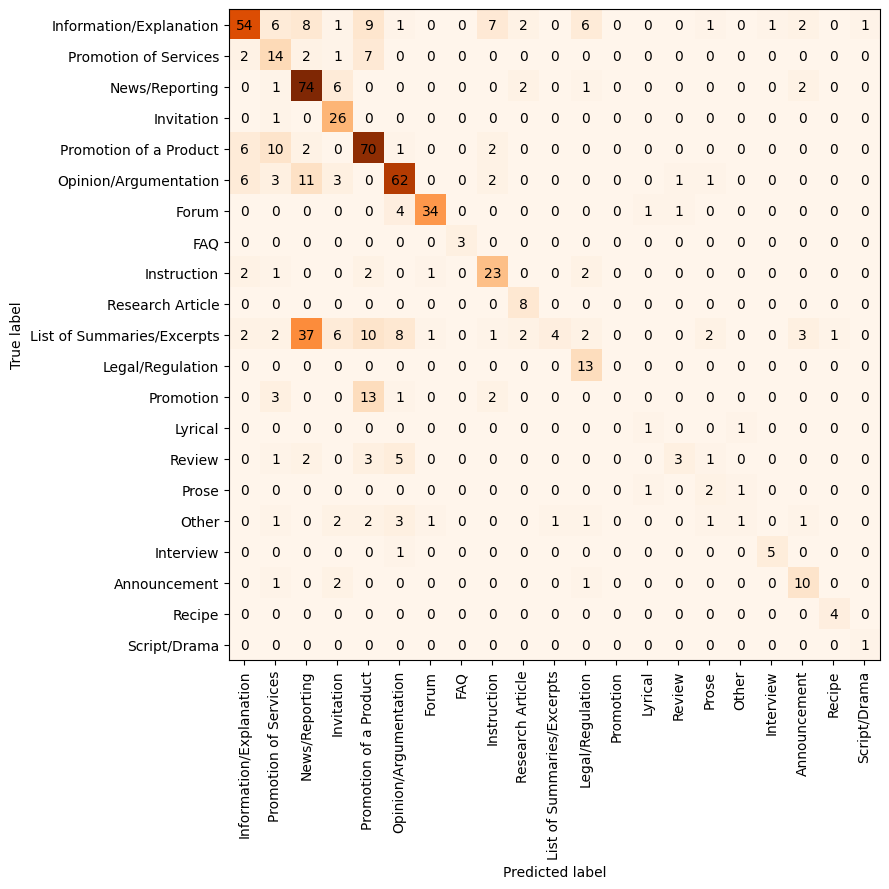

<Figure size 640x480 with 0 Axes>

In [31]:
# Show confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true = ginco_testing["primary_level_1"].to_list()
y_pred = ginco_testing["GPT-4o"].to_list()
LABELS = list(ginco_testing["primary_level_1"].unique())

print(classification_report(y_true, y_pred))

# Plot the confusion matrix:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(9, 9))
plt.imshow(cm, cmap="Oranges")
for (i, j), z in np.ndenumerate(cm):
    plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
classNames = LABELS
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=90)
plt.yticks(tick_marks, classNames)
#plt.title(f"{model_name}")

plt.tight_layout()
fig1 = plt.gcf()
plt.show()
plt.draw()

In [44]:
# Scores if we discard List of Summaries and Other

ginco_clean_labels = ginco_testing[ginco_testing["primary_level_1"] != "List of Summaries/Excerpts"]
ginco_clean_labels = ginco_clean_labels[ginco_clean_labels["primary_level_1"] != "Other"]
ginco_clean_labels.shape

(578, 14)

In [45]:
evaluate(ginco_clean_labels, "primary_level_1", "GPT-4o")

Macro f1: 0.663, Micro f1: 0.705


{'micro_F1': 0.7053726169844021, 'macro_F1': 0.6627934200421227}

### Inter-annotator agreement

In [25]:
# Create a function which calculates the Krippendorff's alpha:
def krip_alpha(table, an1_column, an2_column):
    """
    Args:
    - table (DataFrame): This function takes a dataframe where the first column should be labels by the first annotator and the second labels by the other annotator.
    - an1_column: Name of the column with labels of the 1st annotator.
    - an2_column: Name of the column with labels of the 2nd annotator.

    This function prints out the nominal Krippendorff's alpha.
    """
    import krippendorff
    import numpy as np
    from collections import Counter

    # Drop NaN values if there are any
    #table = table.dropna()

    # Use only the first 2 columns
    table = table[[an1_column, an2_column]]

    table_to_list = []

    for column in table.columns:
        column_list = table[column].tolist()
        table_to_list.append(column_list)

    labels = table_to_list

    print("Number of instances: ",len(labels[0]))

    distr=dict([(b,a) for a,b in enumerate(list(Counter(labels[0]+labels[1]).keys()))])

    labels[0]=[distr[e] for e in labels[0]]
    labels[1]=[distr[e] for e in labels[1]]

    #Krippendorff's alpha
    krip = krippendorff.alpha(reliability_data=labels,level_of_measurement='nominal')
    print("Krippendorff's Alpha: ", krip)
    return krip

In [25]:
agreement_results = {}

In [26]:
from itertools import combinations, combinations_with_replacement

pairs = list(combinations(['Mojca', 'Taja', 'GPT-4o'], 2))
pairs

[('Mojca', 'Taja'), ('Mojca', 'GPT-4o'), ('Taja', 'GPT-4o')]

In [27]:
for pair in pairs:
	agreement_results[f"{pair[0]} & {pair[1]}"] = krip_alpha(ginco_testing, pair[0], pair[1])

agreement_results

Number of instances:  673
Krippendorff's Alpha:  0.777069907292021
Number of instances:  673
Krippendorff's Alpha:  0.577292155548106
Number of instances:  673
Krippendorff's Alpha:  0.5540188045272342


{'Mojca & Taja': 0.777069907292021,
 'Mojca & GPT-4o': 0.577292155548106,
 'Taja & GPT-4o': 0.5540188045272342}

In [28]:
print(pd.DataFrame({"pair": list(agreement_results.keys()), "nominal Krippendorff Alpha": list(agreement_results.values())}).sort_values(by="nominal Krippendorff Alpha", ascending=False).to_markdown(index=False))

| pair           |   nominal Krippendorff Alpha |
|:---------------|-----------------------------:|
| Mojca & Taja   |                     0.77707  |
| Mojca & GPT-4o |                     0.577292 |
| Taja & GPT-4o  |                     0.554019 |


In [46]:
# Agreement on instances that are not List of Summaries/Excerpts or Other
for pair in pairs:
	agreement_results[f"{pair[0]} & {pair[1]} - List of Summaries/Excerpts and Other removed"] = krip_alpha(ginco_clean_labels, pair[0], pair[1])

agreement_results

Number of instances:  578
Krippendorff's Alpha:  0.7834115240172386
Number of instances:  578
Krippendorff's Alpha:  0.6570121179602952
Number of instances:  578
Krippendorff's Alpha:  0.6480940637808994


{'Mojca & Taja': 0.777069907292021,
 'Mojca & GPT-4o': 0.577292155548106,
 'Taja & GPT-4o': 0.5540188045272342,
 'Mojca_level3 & Taja_level3': 0.8057299230180666,
 'Mojca_level3 & GPT-4o_level3': 0.6204212647437386,
 'Taja_level3 & GPT-4o_level3': 0.6089819308506041,
 'Mojca & Taja - List of Summaries/Excerpts and Other removed': 0.7834115240172386,
 'Mojca & GPT-4o - List of Summaries/Excerpts and Other removed': 0.6570121179602952,
 'Taja & GPT-4o - List of Summaries/Excerpts and Other removed': 0.6480940637808994}

# Analysis of performance if we map the labels to level_3

In [34]:
mapping =  {"Script/Drama":"Other", "Lyrical":"Other","FAQ":"Other","Recipe":"Instruction", "Research Article":"Information/Explanation", "Review":"Opinion/Argumentation", "Promotion of Services":"Promotion", "Promotion of a Product":"Promotion", "Invitation":"Promotion", "Prose":"Other"}

def map_to_level3(value):
	if value in list(mapping.keys()):
		new_value = mapping[value]
	else:
		new_value = value
	return new_value

In [36]:
ginco_testing["Mojca_level3"] = ginco_testing["Mojca"].apply(map_to_level3)

ginco_testing[["Mojca", "Mojca_level3"]].head(10)

/tmp/ipykernel_1477951/3732618227.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ginco_testing["Mojca_level3"] = ginco_testing["Mojca"].apply(map_to_level3)


,Mojca,Mojca_level3
0,Information/Explanation,Information/Explanation
1,Information/Explanation,Information/Explanation
2,News/Reporting,News/Reporting
3,Invitation,Promotion
5,Information/Explanation,Information/Explanation
6,News/Reporting,News/Reporting
7,Opinion/Argumentation,Opinion/Argumentation
9,Opinion/Argumentation,Opinion/Argumentation
10,Forum,Forum
13,FAQ,Other


In [41]:
ginco_testing["Taja_level3"] = ginco_testing["Taja"].apply(map_to_level3)
ginco_testing["GPT-4o_level3"] = ginco_testing["GPT-4o"].apply(map_to_level3)
ginco_testing["primary_level_3"] = ginco_testing["primary_level_1"].apply(map_to_level3)

/tmp/ipykernel_1477951/2229946543.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ginco_testing["Taja_level3"] = ginco_testing["Taja"].apply(map_to_level3)
/tmp/ipykernel_1477951/2229946543.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ginco_testing["GPT-4o_level3"] = ginco_testing["GPT-4o"].apply(map_to_level3)
/tmp/ipykernel_1477951/2229946543.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


In [39]:
# Calculate Krippendorf alpha
from itertools import combinations, combinations_with_replacement

pairs3 = list(combinations(['Mojca_level3', 'Taja_level3', 'GPT-4o_level3'], 2))

for pair in pairs3:
	agreement_results[f"{pair[0]} & {pair[1]}"] = krip_alpha(ginco_testing, pair[0], pair[1])

agreement_results

Number of instances:  673
Krippendorff's Alpha:  0.8057299230180666
Number of instances:  673
Krippendorff's Alpha:  0.6204212647437386
Number of instances:  673
Krippendorff's Alpha:  0.6089819308506041


{'Mojca & Taja': 0.777069907292021,
 'Mojca & GPT-4o': 0.577292155548106,
 'Taja & GPT-4o': 0.5540188045272342,
 'Mojca_level3 & Taja_level3': 0.8057299230180666,
 'Mojca_level3 & GPT-4o_level3': 0.6204212647437386,
 'Taja_level3 & GPT-4o_level3': 0.6089819308506041}

In [42]:
# Evaluate
evaluate(ginco_testing, "primary_level_3", "GPT-4o_level3")

Macro f1: 0.655, Micro f1: 0.682


{'micro_F1': 0.6820208023774146, 'macro_F1': 0.6547678535456363}

                            precision    recall  f1-score   support

              Announcement       0.56      0.71      0.62        14
                     Forum       0.92      0.85      0.88        40
   Information/Explanation       0.74      0.60      0.66       107
               Instruction       0.64      0.77      0.70        35
                 Interview       0.83      0.83      0.83         6
          Legal/Regulation       0.50      1.00      0.67        13
List of Summaries/Excerpts       0.80      0.05      0.09        81
            News/Reporting       0.54      0.86      0.67        86
     Opinion/Argumentation       0.78      0.68      0.73       104
                     Other       0.63      0.50      0.56        24
                 Promotion       0.70      0.89      0.78       163

                  accuracy                           0.68       673
                 macro avg       0.70      0.70      0.65       673
              weighted avg       0.71      0.6

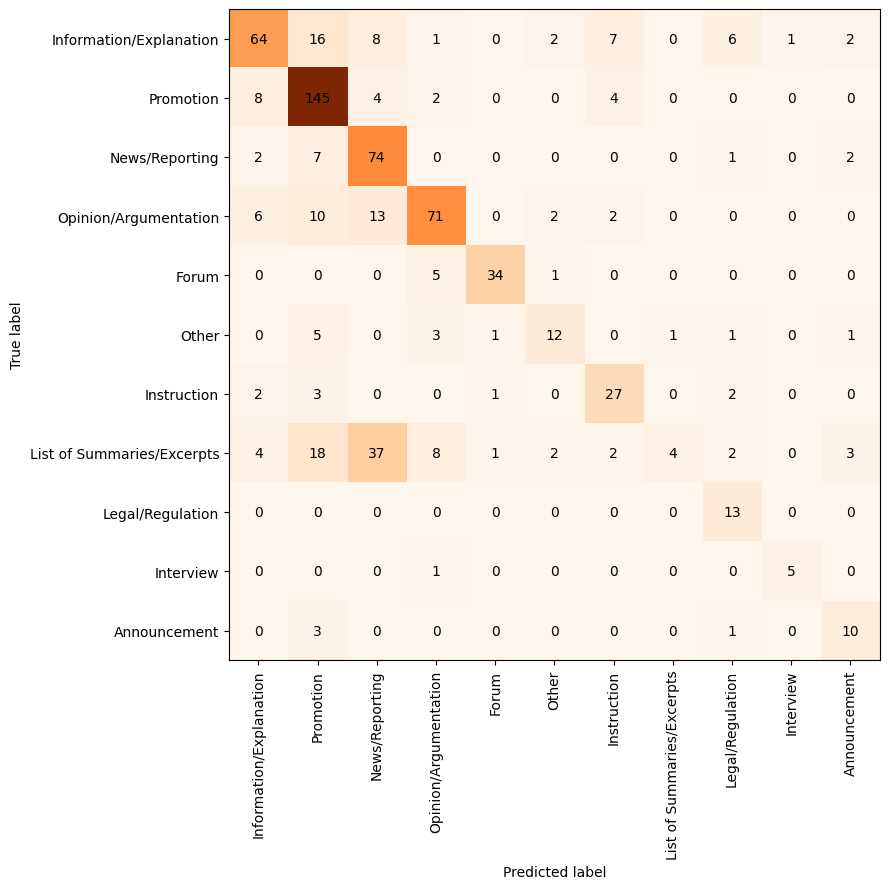

<Figure size 640x480 with 0 Axes>

In [43]:
# Show confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true = ginco_testing["primary_level_3"].to_list()
y_pred = ginco_testing["GPT-4o_level3"].to_list()
LABELS = list(ginco_testing["primary_level_3"].unique())

print(classification_report(y_true, y_pred))

# Plot the confusion matrix:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(9, 9))
plt.imshow(cm, cmap="Oranges")
for (i, j), z in np.ndenumerate(cm):
    plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
classNames = LABELS
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=90)
plt.yticks(tick_marks, classNames)
#plt.title(f"{model_name}")

plt.tight_layout()
fig1 = plt.gcf()
plt.show()
plt.draw()

# Analysis of performance if we map the labels to X-GENRE categorization

We map the original annotators' labels to the X-GENRE schema and use the GPT model to predict the X-GENRE labels.

In [3]:
# Open the dataset with predictions
ginco_testing = pd.read_json("/home/tajak/IPTC-News-Topic-Categorization/extension-to-genre/datasets/GINCO-train-and-test-split-with-GPT-predictions.jsonl", orient="records", lines=True)

print(ginco_testing.shape)

ginco_testing.head(2)

(673, 9)


,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,GPT-4o
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,News/Reporting


In [4]:
mapping = {'FAQ': 'discarded', 'List of Summaries/Excerpts': 'discarded', 'Forum': 'Forum', 'Information/Explanation': 'Information/Explanation', 'Research Article': 'Information/Explanation', 'Instruction': 'Instruction', 'Recipe': 'Instruction', 'Legal/Regulation': 'Legal', 'Announcement': 'News', 'News/Reporting': 'News', 'Opinionated News': 'News', 'Opinion/Argumentation': 'Opinion/Argumentation', 'Review': 'Opinion/Argumentation', 'Call': 'Other', 'Correspondence': 'Other', 'Interview': 'Other', 'Other': 'Other', 'Script/Drama': 'Other', 'Invitation': 'Promotion', 'Promotion': 'Promotion', 'Promotion of a Product': 'Promotion', 'Promotion of Services': 'Promotion', 'Lyrical': 'Prose/Lyrical', 'Prose': 'Prose/Lyrical'}


def map_to_xgenre(value):
	if value in list(mapping.keys()):
		new_value = mapping[value]
	else:
		new_value = value
	return new_value

In [5]:
ginco_testing["Mojca_xgenre"] = ginco_testing["Mojca"].apply(map_to_xgenre)
ginco_testing["Taja_xgenre"] = ginco_testing["Taja"].apply(map_to_xgenre)
ginco_testing["primary_level_1_xgenre"] = ginco_testing["primary_level_1"].apply(map_to_xgenre)

ginco_testing[["primary_level_1", "primary_level_1_xgenre", "Mojca", "Mojca_xgenre", "Taja", "Taja_xgenre"]].head(5)

,primary_level_1,primary_level_1_xgenre,Mojca,Mojca_xgenre,Taja,Taja_xgenre
0,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation
1,Promotion of Services,Promotion,Information/Explanation,Information/Explanation,Promotion of Services,Promotion
2,News/Reporting,News,News/Reporting,News,Invitation,Promotion
3,Invitation,Promotion,Invitation,Promotion,Invitation,Promotion
4,Promotion of a Product,Promotion,Information/Explanation,Information/Explanation,Promotion of a Product,Promotion


In [7]:
# Remove instances where any of the annotators (or the final label) assigned the label that is now "discarded"

ginco_testing = ginco_testing[ginco_testing["primary_level_1_xgenre"] != "discarded"]
ginco_testing = ginco_testing[ginco_testing["Taja_xgenre"] != "discarded"]
ginco_testing = ginco_testing[ginco_testing["Mojca_xgenre"] != "discarded"]

ginco_testing.shape

(581, 12)

## Apply GPT model with X-GENRE labels

In [8]:
labels = list(ginco_testing["primary_level_1_xgenre"].unique())
labels

['Information/Explanation',
 'Promotion',
 'News',
 'Opinion/Argumentation',
 'Forum',
 'Instruction',
 'Legal',
 'Prose/Lyrical',
 'Other']

In [12]:
labels_dict = {x:labels.index(x) for x in labels}
reverse_dict = {labels.index(x):x for x in labels}

print(labels_dict)
print(reverse_dict)

{'Information/Explanation': 0, 'News': 1, 'Promotion': 2, 'Opinion/Argumentation': 3, 'Forum': 4, 'Instruction': 5, 'Other': 6, 'Legal': 7, 'Prose/Lyrical': 8}
{0: 'Information/Explanation', 1: 'News', 2: 'Promotion', 3: 'Opinion/Argumentation', 4: 'Forum', 5: 'Instruction', 6: 'Other', 7: 'Legal', 8: 'Prose/Lyrical'}


In [14]:
labels_dict

{'Information/Explanation': 0,
 'News': 1,
 'Promotion': 2,
 'Opinion/Argumentation': 3,
 'Forum': 4,
 'Instruction': 5,
 'Other': 6,
 'Legal': 7,
 'Prose/Lyrical': 8}

In [18]:
task_introduction = """
### Task
	Your task is to classify the provided text into a genre label, meaning that you need to recognize what is the genre of the text. We define a (text) genre as 'essentially a document type based on purpose, form and content'. You will be provided with a text in Slovenian, delimited by single quotation marks. Always provide a label, even if you are not sure.\n\n
"""

labels_dict_with_description = {
 'Information/Explanation - an objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Common features: objective/factual, explanation/definition of a concept (x is …), enumeration.': 0,
 'News - an objective or subjective text which reports on an event recent at the time of writing or coming in the near future. Common features: adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense.': 1,
 'Promotion - a subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. Common features: contains adjectives/adverbs that promote something (high-quality, perfect, amazing), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks.': 2,
 'Opinion/Argumentation - a subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. This genre includes a subjective narration of a personal experience as well. Common features: adjectives/adverbs that convey opinion, words that convey (un)certainty (certainly, surely), 1st person, exclamation marks.': 3,
 'Forum - a text in which people discuss a certain topic in form of comments. Common features: multiple authors, informal language, subjective (the writers express their opinions), written in 1st person.': 4,
 'Instruction - an objective text which instructs the readers on how to do something. Common features: multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …).': 5,
 'Other - a text that which does not fall under any of other genre categories. Examples: quiz, survey, introduction into the magazine’s content, introduction to a video, summary of a movie/book, speech (if it cannot fit under Opinion/Argumentation), sermon, user’s consent for data sharing, texts inviting the readers to participate in a giveaway, to submit their proposals or fill out a form,exam, exercise, worksheet, call for papers, correspondence, interviews, scripts (for TV shows, theatre).': 6,
 'Legal -an objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Common features: objective/factual, legal terms, 3rd person.': 7,
 'Prose/Lyrical - a literary text that consists of paragraphs or verses. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art.': 8}

xgenre_description = f""" 
### Output format
	Return a valid JSON dictionary with the following key: 'label' and a value should be an integer which represents one of the labels according to the following dictionary: {labels_dict_with_description}.
"""

prompt_xgenre = task_introduction + xgenre_description

In [17]:
texts = ginco_testing["Slovene_text"].to_list()

texts[:2]

['JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj projekta Najdi svojo službo je bil aktivno sodelovanje šole z gospodarstvom, dijaki so se seznanili s smernicami gospodarskega razvoja kraške regije v prihodnosti, ter z razvojem in potrebami obstoječih podjetij in zato k usmerjanju mladih k ciljnemu izobraževanju za potrebe delodajalcev. <p/> Projekt Najdi svojo službo je v okviru razpisa Skriti zaklad v šolskem letu 2003/04 odobrilo Ministrstvo za šolstvo in šport Republike Slovenije. Projekt je trajal dve šolski leti.',
 'Projekt INNOVAge in zavod Oreli <p/> Zavod Oreli se je odzval povabilu Razvojnega c entra Srca Slovenije, ki je v okviru projekta INNOVAge imelo nalogo, da na študijski obisk v Helsinke na Finskem, pripelje zunanje strokovnjake na področju oskrbe starostnikov, teleoskrbe, e-zdravja, eko-inovacij v stanovanjih in hišah, prilagojenih starostnikom. V tem projektu sodeluje 13 evropskih partnerjev, med njimi Razvojni center Srca Slovenije kot edini slovenski partner. <p/> Gl

In [19]:
def predict_with_GPT_xgenre(sample):
	prompt = prompt_xgenre
	responses = []

	for text in tqdm(texts):
		completion = client.chat.completions.create(model="gpt-4o-2024-05-13",
		response_format={ "type": "json_object"},
		messages=[
		{
			"role": "user",
			"content": prompt + f"\nText: '{text}'"}
		],
		temperature = 0)
		response=completion.choices[0].message.content

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Convert the string into a dictionary
		response = json.loads(response)

		# Get out a label
		try:
			predicted = reverse_dict[response["label"]]
			responses.append(predicted)
		# add a possibility of something going wrong
		except:
			responses.append("error")

	sample[f"GPT-4o_xgenre"] = responses

	# Evaluate the performance of the model
	from sklearn.metrics import f1_score

	# Get the true labels
	y_true = sample["primary_level_1_xgenre"].to_list()
	LABELS = list(sample["primary_level_1_xgenre"].unique())
	y_pred = sample[f"GPT-4o_xgenre"].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}
	return [sample, scores]

In [20]:
results = []

In [21]:
# Predict
ginco_testing, current_scores = predict_with_GPT_xgenre(ginco_testing)
results.append({"setup": f"GPT-4o_xgenre", "macro_F1": current_scores["macro_F1"], "micro_F1": current_scores["micro_F1"]})
print(current_scores)

100%|██████████| 581/581 [05:14<00:00,  1.85it/s]

Macro f1: 0.726, Micro f1: 0.768
{'micro_F1': 0.7676419965576592, 'macro_F1': 0.7263147828888642}


Prediction on 581 instances cost 4.38$ and took 5 minutes.

In [22]:
ginco_testing.head(2)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,GPT-4o,Mojca_xgenre,Taja_xgenre,primary_level_1_xgenre,GPT-4o_xgenre
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,News/Reporting,Information/Explanation,Promotion,Promotion,Information/Explanation


In [23]:
# Save the dataset with predictions
ginco_testing.to_json("/home/tajak/IPTC-News-Topic-Categorization/extension-to-genre/datasets/GINCO-train-and-test-split-with-X-GENRE-GPT-predictions.jsonl", orient="records", lines=True)

## Analysis

In [2]:
# Open the dataset with predictions
ginco_testing = pd.read_json("/home/tajak/IPTC-News-Topic-Categorization/extension-to-genre/datasets/GINCO-train-and-test-split-with-X-GENRE-GPT-predictions.jsonl", orient="records", lines=True)

ginco_testing.head(2)

,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,GPT-4o,Mojca_xgenre,Taja_xgenre,primary_level_1_xgenre,GPT-4o_xgenre
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,News/Reporting,Information/Explanation,Promotion,Promotion,Information/Explanation


In [29]:
agreement_results = {}

In [30]:
# Calculate Krippendorf alpha
from itertools import combinations, combinations_with_replacement

pairs3 = list(combinations(['Mojca_xgenre', 'Taja_xgenre', 'GPT-4o_xgenre'], 2))

for pair in pairs3:
	agreement_results[f"{pair[0]} & {pair[1]}"] = krip_alpha(ginco_testing, pair[0], pair[1])

agreement_results

Number of instances:  581
Krippendorff's Alpha:  0.8103285532764567
Number of instances:  581
Krippendorff's Alpha:  0.7010824510724081
Number of instances:  581
Krippendorff's Alpha:  0.7030464311369424


{'Mojca_xgenre & Taja_xgenre': 0.8103285532764567,
 'Mojca_xgenre & GPT-4o_xgenre': 0.7010824510724081,
 'Taja_xgenre & GPT-4o_xgenre': 0.7030464311369424}

In [35]:
print(pd.DataFrame({"pair": list(agreement_results.keys()), "nominal Krippendorff Alpha": list(agreement_results.values())}).sort_values(by="nominal Krippendorff Alpha", ascending=False).to_markdown(index=False))

| pair                         |   nominal Krippendorff Alpha |
|:-----------------------------|-----------------------------:|
| Mojca_xgenre & Taja_xgenre   |                     0.810329 |
| Taja_xgenre & GPT-4o_xgenre  |                     0.703046 |
| Mojca_xgenre & GPT-4o_xgenre |                     0.701082 |


In [33]:
# Evaluate
evaluate(ginco_testing, "primary_level_1_xgenre", "GPT-4o_xgenre")

Macro f1: 0.726, Micro f1: 0.768


{'micro_F1': 0.7676419965576592, 'macro_F1': 0.7263147828888642}

                         precision    recall  f1-score   support

                  Forum       0.95      0.93      0.94        40
Information/Explanation       0.65      0.73      0.68       106
            Instruction       0.83      0.83      0.83        35
                  Legal       0.68      1.00      0.81        13
                   News       0.71      0.81      0.76        97
  Opinion/Argumentation       0.90      0.61      0.73       101
                  Other       0.75      0.15      0.25        20
              Promotion       0.81      0.86      0.83       163
          Prose/Lyrical       0.55      1.00      0.71         6

               accuracy                           0.77       581
              macro avg       0.76      0.77      0.73       581
           weighted avg       0.78      0.77      0.76       581



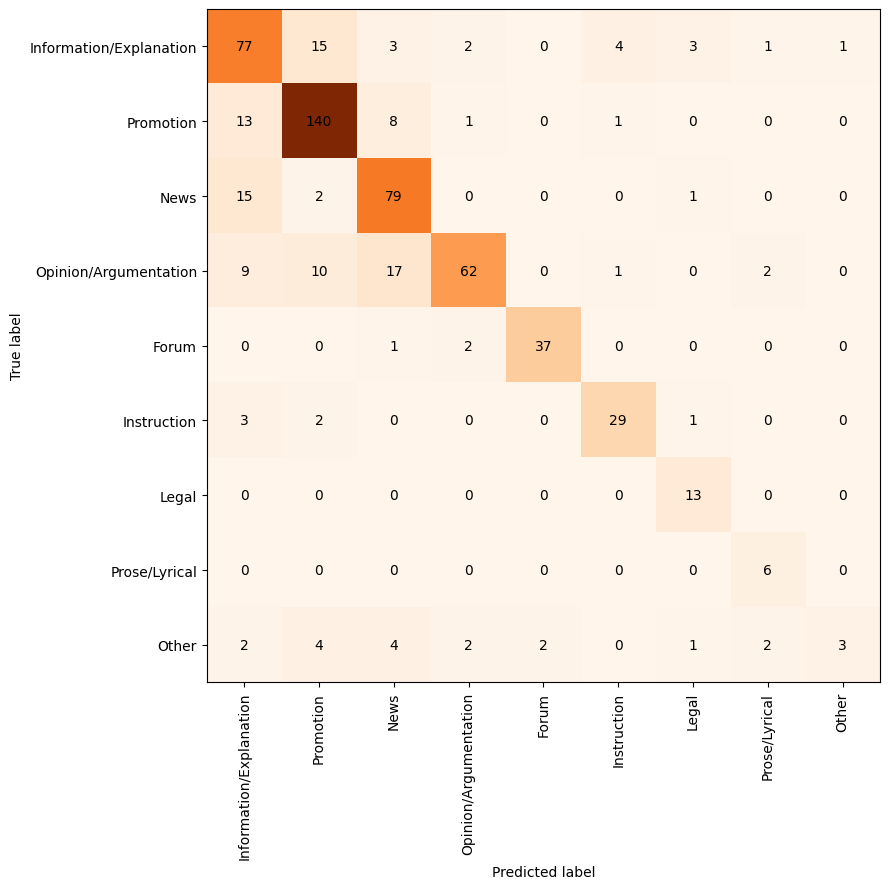

<Figure size 640x480 with 0 Axes>

In [36]:
# Show confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true = ginco_testing["primary_level_1_xgenre"].to_list()
y_pred = ginco_testing["GPT-4o_xgenre"].to_list()
LABELS = list(ginco_testing["primary_level_1_xgenre"].unique())

print(classification_report(y_true, y_pred))

# Plot the confusion matrix:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(9, 9))
plt.imshow(cm, cmap="Oranges")
for (i, j), z in np.ndenumerate(cm):
    plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
classNames = LABELS
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=90)
plt.yticks(tick_marks, classNames)
#plt.title(f"{model_name}")

plt.tight_layout()
fig1 = plt.gcf()
plt.show()
plt.draw()

In [18]:
from itertools import combinations, combinations_with_replacement

pairs3 = list(combinations(['Mojca_xgenre', 'Taja_xgenre', 'GPT-4o_xgenre'], 2))
pairs3

[('Mojca_xgenre', 'Taja_xgenre'),
 ('Mojca_xgenre', 'GPT-4o_xgenre'),
 ('Taja_xgenre', 'GPT-4o_xgenre')]

In [10]:
labels = list(ginco_testing["primary_level_1_xgenre"].unique())
labels

['Information/Explanation',
 'Promotion',
 'News',
 'Opinion/Argumentation',
 'Forum',
 'Instruction',
 'Legal',
 'Prose/Lyrical',
 'Other']

In [19]:
# Calculate label-level agreement based on F1 scores for all annotators
from sklearn.metrics import classification_report

agreement_F1 = {}

for pair in pairs3:
	y_true = ginco_testing[pair[0]].to_list()
	y_pred = ginco_testing[pair[1]].to_list()
	LABELS = list(ginco_testing[pair[0]].unique())

	current_results = classification_report(y_true, y_pred, output_dict = True)
	final_results = {}
	for label in labels:
		final_results[label] = current_results[label]["f1-score"]
	agreement_F1[f"{pair[0]}-{pair[1]}"] = final_results

agreement_F1

{'Mojca_xgenre-Taja_xgenre': {'Information/Explanation': 0.7850467289719626,
  'Promotion': 0.8614457831325302,
  'News': 0.8756756756756757,
  'Opinion/Argumentation': 0.8598130841121495,
  'Forum': 0.961038961038961,
  'Instruction': 0.8181818181818182,
  'Legal': 0.896551724137931,
  'Prose/Lyrical': 0.9090909090909091,
  'Other': 0.5294117647058824},
 'Mojca_xgenre-GPT-4o_xgenre': {'Information/Explanation': 0.6956521739130435,
  'Promotion': 0.8387096774193549,
  'News': 0.7352941176470589,
  'Opinion/Argumentation': 0.6888888888888889,
  'Forum': 0.9090909090909091,
  'Instruction': 0.7692307692307693,
  'Legal': 0.8484848484848485,
  'Prose/Lyrical': 0.625,
  'Other': 0.125},
 'Taja_xgenre-GPT-4o_xgenre': {'Information/Explanation': 0.6666666666666666,
  'Promotion': 0.8011869436201781,
  'News': 0.7414634146341463,
  'Opinion/Argumentation': 0.7558139534883721,
  'Forum': 0.9230769230769231,
  'Instruction': 0.8450704225352113,
  'Legal': 0.8823529411764706,
  'Prose/Lyrical': 

In [20]:
pd.DataFrame(agreement_F1)

,Mojca_xgenre-Taja_xgenre,Mojca_xgenre-GPT-4o_xgenre,Taja_xgenre-GPT-4o_xgenre
Information/Explanation,0.785047,0.695652,0.666667
Promotion,0.861446,0.838710,0.801187
News,0.875676,0.735294,0.741463
Opinion/Argumentation,0.859813,0.688889,0.755814
Forum,0.961039,0.909091,0.923077
Instruction,0.818182,0.769231,0.845070
Legal,0.896552,0.848485,0.882353
Prose/Lyrical,0.909091,0.625000,0.705882
Other,0.529412,0.125000,0.230769


In [21]:
print(pd.DataFrame(agreement_F1).to_markdown())

|                         |   Mojca_xgenre-Taja_xgenre |   Mojca_xgenre-GPT-4o_xgenre |   Taja_xgenre-GPT-4o_xgenre |
|:------------------------|---------------------------:|-----------------------------:|----------------------------:|
| Information/Explanation |                   0.785047 |                     0.695652 |                    0.666667 |
| Promotion               |                   0.861446 |                     0.83871  |                    0.801187 |
| News                    |                   0.875676 |                     0.735294 |                    0.741463 |
| Opinion/Argumentation   |                   0.859813 |                     0.688889 |                    0.755814 |
| Forum                   |                   0.961039 |                     0.909091 |                    0.923077 |
| Instruction             |                   0.818182 |                     0.769231 |                    0.84507  |
| Legal                   |                   0.896552 |

In [37]:
# Results if we discard category other

ginco_testing_noother = ginco_testing[ginco_testing["primary_level_1_xgenre"] != "Other"]
ginco_testing_noother = ginco_testing_noother[ginco_testing_noother["Mojca_xgenre"] != "Other"]
ginco_testing_noother = ginco_testing_noother[ginco_testing_noother["Taja_xgenre"] != "Other"]

print(ginco_testing_noother.shape)

(556, 13)


In [40]:
# Calculate Krippendorf alpha
from itertools import combinations, combinations_with_replacement

pairs3 = list(combinations(['Mojca_xgenre', 'Taja_xgenre', 'GPT-4o_xgenre'], 2))

for pair in pairs3:
	agreement_results[f"{pair[0]} & {pair[1]}"] = krip_alpha(ginco_testing_noother, pair[0], pair[1])

agreement_results

Number of instances:  556
Krippendorff's Alpha:  0.8350742540988704
Number of instances:  556
Krippendorff's Alpha:  0.7281248432939855
Number of instances:  556
Krippendorff's Alpha:  0.7308252189043669


{'Mojca_xgenre & Taja_xgenre': 0.8350742540988704,
 'Mojca_xgenre & GPT-4o_xgenre': 0.7281248432939855,
 'Taja_xgenre & GPT-4o_xgenre': 0.7308252189043669}

In [41]:
print(pd.DataFrame({"pair": list(agreement_results.keys()), "nominal Krippendorff Alpha": list(agreement_results.values())}).sort_values(by="nominal Krippendorff Alpha", ascending=False).to_markdown(index=False))

| pair                         |   nominal Krippendorff Alpha |
|:-----------------------------|-----------------------------:|
| Mojca_xgenre & Taja_xgenre   |                     0.835074 |
| Taja_xgenre & GPT-4o_xgenre  |                     0.730825 |
| Mojca_xgenre & GPT-4o_xgenre |                     0.728125 |


In [42]:
# Evaluate
evaluate(ginco_testing_noother, "primary_level_1_xgenre", "GPT-4o_xgenre")

Macro f1: 0.811, Micro f1: 0.794


{'micro_F1': 0.7938793879387939, 'macro_F1': 0.8111613353004804}

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

                         precision    recall  f1-score   support

                  Forum       1.00      0.92      0.96        39
Information/Explanation       0.68      0.73      0.70       106
            Instruction       0.83      0.83      0.83        35
                  Legal       0.72      1.00      0.84        13
                   News       0.73      0.82      0.77        96
  Opinion/Argumentation       0.93      0.62      0.74       100
                  Other       0.00      0.00      0.00         0
              Promotion       0.83      0.86      0.84       161
          Prose/Lyrical       0.67      1.00      0.80         6

               accuracy                           0.79       556
              macro avg       0.71      0.75      0.72       556
           weighted avg       0.81      0.79      0.79       556



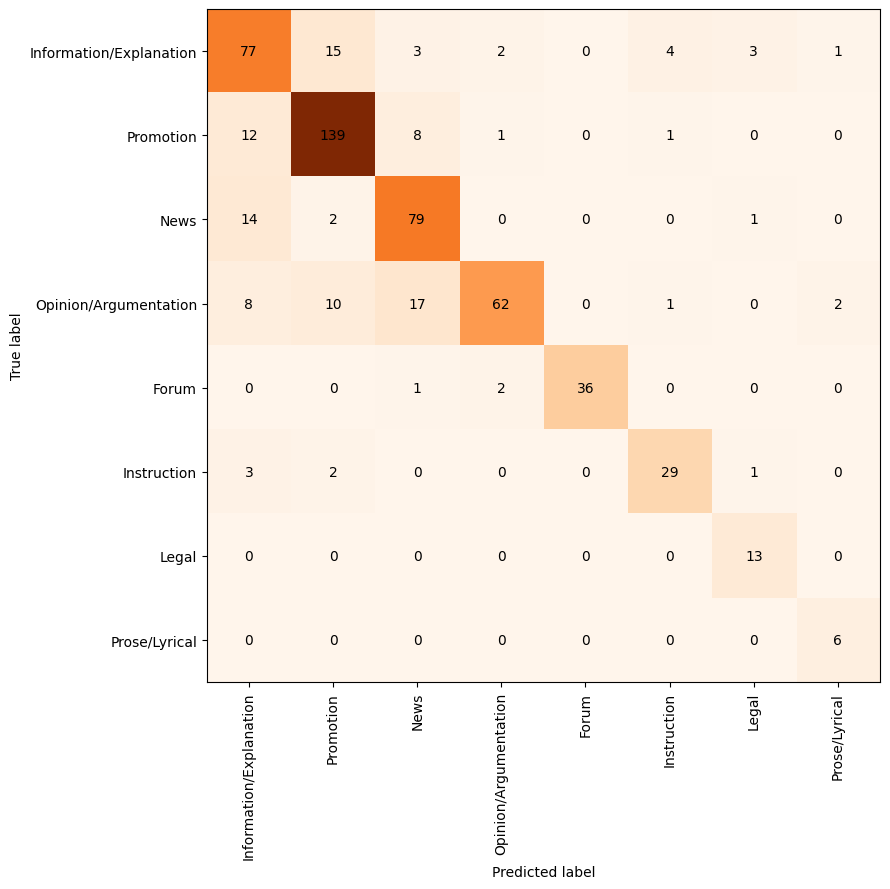

<Figure size 640x480 with 0 Axes>

In [43]:
# Show confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true = ginco_testing_noother["primary_level_1_xgenre"].to_list()
y_pred = ginco_testing_noother["GPT-4o_xgenre"].to_list()
LABELS = list(ginco_testing_noother["primary_level_1_xgenre"].unique())

print(classification_report(y_true, y_pred))

# Plot the confusion matrix:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(9, 9))
plt.imshow(cm, cmap="Oranges")
for (i, j), z in np.ndenumerate(cm):
    plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
classNames = LABELS
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=90)
plt.yticks(tick_marks, classNames)
#plt.title(f"{model_name}")

plt.tight_layout()
fig1 = plt.gcf()
plt.show()
plt.draw()